# BoxCar Ridesharing Discrete-Event Simulation Study — Squareshire

## Introduction

BoxCar are a ride-sharing company in Squareshire (a 20×20 mile square region), operating using a company developed application to match available taxis (drivers) with customers (riders).

The goal of this project is to evaluate BoxCar's system performance through rider and driver satisfaction, and to propose improvements. 

We evaluate rider satisfaction in this report through the metrics: 1. number of rider abandonments due to driver unavailability; and 2. rider waiting times for pick-ups. 
And driver satisfaction through the metrics: 1. average earnings per hour; 2. fairness among drivers; and 3. sufficient rest time

Through extensive discussion with BoxCar executives, we have an outline of the underlying statistical assumptions that the company believes the system follows. Furthermore, we have a 1000 hour cut of company operational data, running from 13:00 01/12/2025 until approximately 24:00 11-01-2026.

 A note of caution regarding testing BoxCar's system assumptions: we have one cut of data that happens to run over the festive period. It is conceivable that both driver and rider behaviour could be be seasonal, and therefore we could be trying to test sound, representative assumptions against a possibly known period of atypical behaviour. We do not have clear direction from BoxCar regarding this concern. In the event that BoxCar's assumptions are not supported by this cut of the data, we intend to model firstly BoxCar's assumptions, then secondly a set of assumptions derived from the cut of data. Moreover, any improvements we suggest will again be tested against both sets of assumptions.

The analysis in this report is structured as follows:

1. **Input Data Analysis** — We test how BoxCar's underlying system assumptions match up against the provided driver and rider datasets
2. **Simulation Model** — We implement a full discrete-event simulation of the Boxcar ride-sharing system operating in Squareshire 
3. **Baseline vs Calibrated Scenarios** — Comparing simulation model performance using BoxCar's assumed parameters against data-driven ones, across 100 simulations
4. **Improvement Proposals** — Testing interventions to improve rider and driver satisfaction, across 100 simulations
5. **Conclusions and Recommendations**



In [30]:
import heapq
import random
import math
import statistics
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import ast
from scipy import stats
from IPython.display import display, Image

---
# Input Data Analysis

We examine the provided datasets to validate BoxCar's assumptions and calibrate the simulation parameters. All hypothesis testing reported is performed at the 95% significance level.


## 1.1 Driver Data

In [31]:
df_driver = pd.read_excel("drivers.xlsx")
#print(f"Driver records: {len(df_driver)}")
#df_driver.head()

### Driver Inter-Arrival Times

BoxCar assumption, $H_0$: the drivers make themselves available in the app at random times with an inter-arrival of exponential(3/hour)

$H_a$: driver's do not make themselves available in the app with an inter-arrival time of exponential(3/hour)

We performed a Chi-squared goodness of fit test, resulting in a test statistics T = 740.9309, where T~$\chi^2_{24}$, with P(T>740.9309) < 0.001. Therefore on the evidence of the sample data we would have to reject the null hypothesis, i.e. Boxcar's assumption.

The sample data looked broadly consistent with an exponential distribution, so we estimated the rate parameter and repeated our test.

$H_0$: the drivers make themselves available in the app at random times with an inter-arrival of exponential(4.74/hour)

$H_a$: driver's do not make themselves available in the app with an inter-arrival time of exponential(4.74/hour)

Again, we performed a Chi-squared goodness of fit test, resulting in a test statistic T = 30.79072, where T~$\chi^2_{23}$, with P(T>30.79072) = 0.128022. Therefore, we do not have the evidence to reject the null hypothesis that drivers make themselves available in the app with an inter-arrival of exponential(4.74/hour)

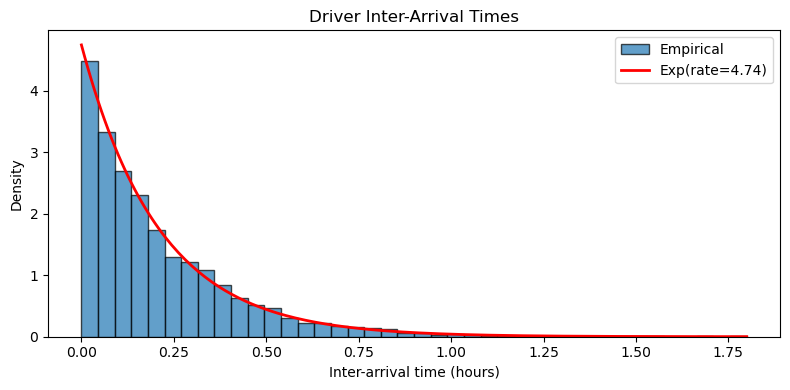

In [32]:
df_d_sorted = df_driver.sort_values("arrival_time")
driver_ia = df_d_sorted["arrival_time"].diff().dropna()
driver_ia_mean = driver_ia.mean()

#print(f"Mean inter-arrival: {driver_ia_mean:.4f} hrs ({driver_ia_mean*60:.1f} min)")
#print(f"Empirical rate: {1/driver_ia_mean:.2f} drivers/hr (spec assumes 3/hr)")

plt.figure(figsize=(8, 4))
plt.hist(driver_ia, bins=40, edgecolor="black", alpha=0.7, density=True, label="Empirical")
from scipy.stats import expon
x = np.linspace(0, driver_ia.max(), 200)
plt.plot(x, expon.pdf(x, scale=driver_ia_mean), "r-", lw=2, label=f"Exp(rate={1/driver_ia_mean:.2f})")
plt.xlabel("Inter-arrival time (hours)")
plt.ylabel("Density")
plt.title("Driver Inter-Arrival Times")
plt.legend()
plt.tight_layout()
plt.show()

### Driver Shift Lengths

BoxCar assumption: Once a driver becomes available, the driver stays available for a random time which is uniformly distributed between 5 and 8 hours and then goes offline.

Examining the sample data, it looks instead that drivers stay available for a uniform random time between 6 and 8 hours.

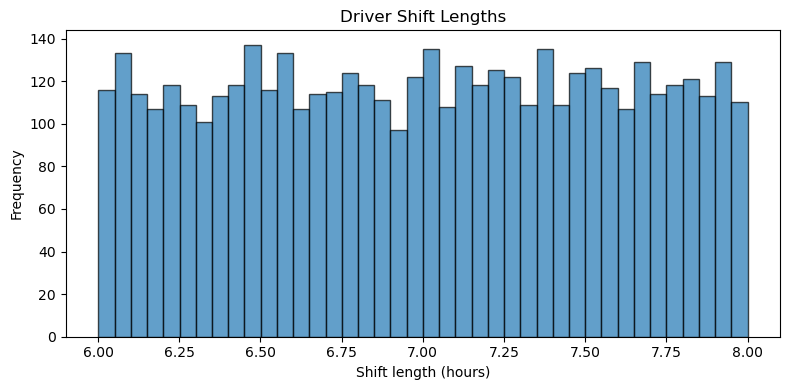

In [33]:
df_driver["shift_length"] = df_driver["offline_time"] - df_driver["arrival_time"]

#print(f"Min shift: {df_driver['shift_length'].min():.2f} hrs")
#print(f"Max shift: {df_driver['shift_length'].max():.2f} hrs")
#print(f"Mean shift: {df_driver['shift_length'].mean():.2f} hrs")

plt.figure(figsize=(8, 4))
plt.hist(df_driver["shift_length"], bins=40, edgecolor="black", alpha=0.7)
plt.xlabel("Shift length (hours)")
plt.ylabel("Frequency")
plt.title("Driver Shift Lengths")
plt.tight_layout()
plt.show()

$H_0$: the drivers' shift lengths follow a uniform(6, 8) distribution

$H_a$: the drivers' shift lengths do not follow a uniform(6, 8) distribution

Again, we performed a Chi-squared goodness of fit test, resulting in a test statistic T = 10.871, where T~$\chi^2_{18}$, with P(T>30.79072) = 0.8997613. Therefore, we do not have the evidence to reject the null hypothesis that drivers' shift lengths follow a uniform(6, 8) distribution.

### Driver Location

BoxCar assumption: the location where a driver becomes available is equally likely to be anywhere in Squareshire, i.e follows a uniform distribution.

$H_0$: Drivers' initial locations follow a uniform distribution across Squareshire

$H_a$: Drivers' initial locations are not uniformly distributed across Squareshire

We split Squareshire into a 20x20 grid, and performed a Chi-squared goodness of fit test, resulting in a test statistic T = 3029.676, where T~$\chi^2+{361}$, with P(T>3029.676) < 0.001. Therefore, on the evidence of the sample data we would reject the null hypothesis, i.e. BoxCar's assumption.

On examining the data, the driver initial x and y coordinates look normally distributed, but are obviously truncated. For the simulation, we decided to fit a (non-truncated) bivariate normal distribution, by sample moments, resulting in a $N_{2}(\mu, \Sigma)$ distribution, with $\mu$ = [9.97391884 11.51331376] and $\Sigma$ = [[19.0502075  0] [0  18.8030244]], and reject the point if it fell outside of the service square.


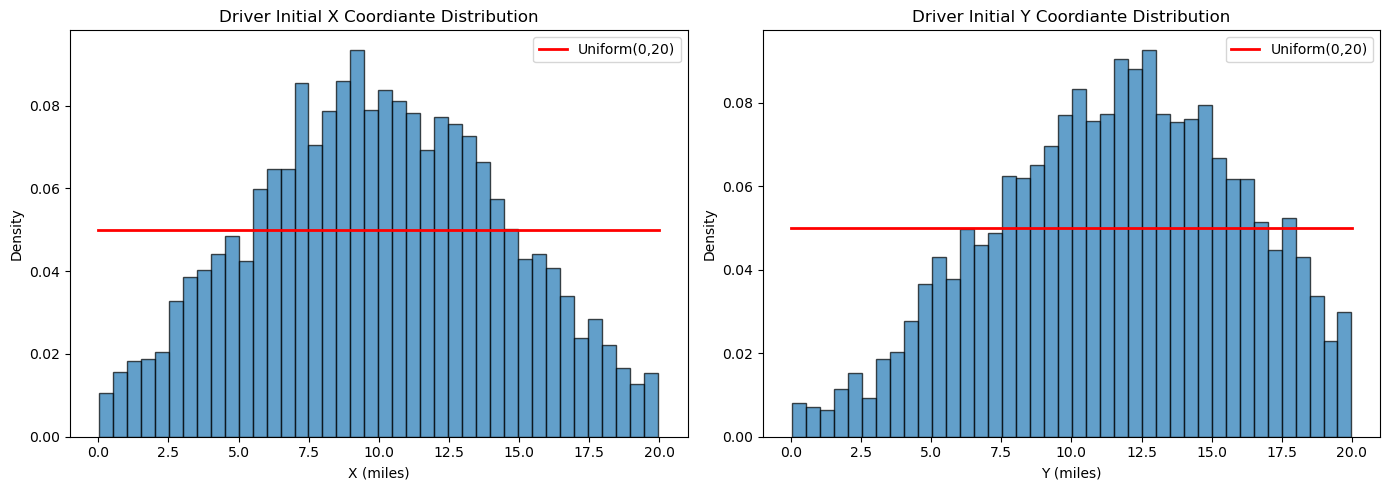

In [34]:
def parse_location(loc_str):
    if pd.isna(loc_str):
        return None, None
    coords = loc_str.strip('()').split(',')
    return float(coords[0]), float(coords[1])

df_driver['init_x'] = df_driver['initial_location'].apply(lambda x: parse_location(x)[0])
df_driver['init_y'] = df_driver['initial_location'].apply(lambda x: parse_location(x)[1])

x = df_driver['init_x'].dropna()
y = df_driver['init_y'].dropna()

fig, axs = plt.subplots(1,2, figsize=(14,5))

axs[0].hist(x,bins=40,density=True,alpha=0.7,edgecolor='black')
xx = np.linspace(0,20,200)
axs[0].plot(xx, stats.uniform.pdf(xx,loc=0,scale=20),
           'r-', linewidth=2, label='Uniform(0,20)')
axs[0].set_title('Driver Initial X Coordiante Distribution')
axs[0].set_xlabel('X (miles)')
axs[0].set_ylabel('Density')
axs[0].legend()

axs[1].hist(y,bins=40,density=True,alpha=0.7,edgecolor='black')
yy = np.linspace(0,20,200)
axs[1].plot(yy, stats.uniform.pdf(yy,loc=0,scale=20),
           'r-', linewidth=2, label='Uniform(0,20)')
axs[1].set_title('Driver Initial Y Coordiante Distribution')
axs[1].set_xlabel('Y (miles)')
axs[1].set_ylabel('Density')
axs[1].legend()

plt.tight_layout()
plt.show()

In [35]:
#print(df_driver["status"].value_counts())
#print()
#print(df_driver["status"].value_counts(normalize=True).round(4))

## 1.2 Rider Data

In [36]:
df_rider = pd.read_excel("riders.xlsx")
#print(f"Rider records: {len(df_rider)}")
#df_rider.head()

### Rider Inter-Arrival Times


BoxCar assumption, $H_0$: the riders arrive at random times to demand a taxi ride with an inter-arrival time of exponential(30/hour)

$H_a$: riders' inter-arrival times do not follow an exponential(30/hour) distribution

We performed a Kolmogorov-Smirnov test, with critical value 1.480, resulting in a test statistics T = 9.94. Therefore on the evidence of the sample data we would have to reject the null hypothesis, i.e. Boxcar's assumption.

The sample data looked broadly consistent with an exponential distribution, so we estimated the rate parameter and repeated our test.

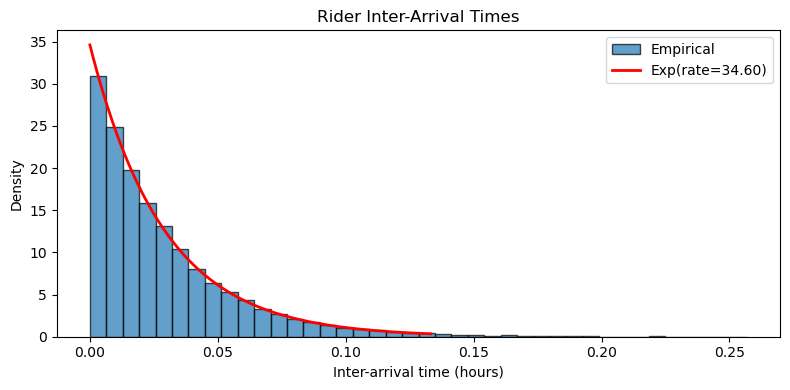

In [37]:
df_r_sorted = df_rider.sort_values("request_time")
rider_ia = df_r_sorted["request_time"].diff().dropna()
rider_ia_mean = rider_ia.mean()

#print(f"Mean inter-arrival: {rider_ia_mean:.4f} hrs ({rider_ia_mean*60:.1f} min)")
#print(f"Empirical rate: {1/rider_ia_mean:.2f} riders/hr (spec assumes 30/hr)")

plt.figure(figsize=(8, 4))
plt.hist(rider_ia, bins=40, edgecolor="black", alpha=0.7, density=True, label="Empirical")
x = np.linspace(0, rider_ia.quantile(0.99), 200)
plt.plot(x, expon.pdf(x, scale=rider_ia_mean), "r-", lw=2, label=f"Exp(rate={1/rider_ia_mean:.2f})")
plt.xlabel("Inter-arrival time (hours)")
plt.ylabel("Density")
plt.title("Rider Inter-Arrival Times")
plt.legend()
plt.tight_layout()
plt.show()

$H_0$: the drivers make themselves available in the app at random times with an inter-arrival of exponential(4.74/hour)

$H_a$: driver's do not make themselves available in the app with an inter-arrival time of exponential(4.74/hour)

Again, we performed a Kolmogorov-Smirnov test, this time with critical value 1.190, resulting in a test statistic T = 0.433. Therefore, we do not have the evidence to reject the null hypothesis that drivers make themselves available in the app with an inter-arrival of exponential(4.74/hour)

### Rider pickup and dropoff locations

BoxCar assumption, $H_0$: rider pickup and dropoff locations are independent of each other and uniformly distributed over Squareshire
$H_a$: rider pickup and dropoff locations are either not independent or not uniformly distributed over Squareshire

We performed a serial test, having first divided Squareshire into a 5x5 grid for pickup locations and a 5x5 grid for dropoff locations, thereby giving 625 possible pickup x dropoff location combinations; resulting in a test statistics T = 58059.15, T~$\chi^2_{624}$, with P(T>58059.15) < 0.00001. Therefore, on the evidence of the sample data we would have to reject the null hypothesis, i.e. BoxCar's assumption.

Looking at the sample data, riders' pickup x coordinates, pickup y coordinates, dropoff x coordinates and dropoff y coordinates all look broadly normally distrubuted, but truncated. We tested the correlation of the four combinations of pickup/dropoff x and y coordinates.

Between drivers' pickup and dropoff x coordinates, T = -0.8979196, T~$t_{34419}$, with P(|T| > 0.8979196) = 0.3692347.

Between drivers' pickup and dropoff y coordinates, T = -1.287377, T~$t_{34419}$, with P(|T| > 1.287377) = 0.1979716.

Between drivers' pickup x coordinates and dropoff y coordinates, T = 1.203628, T~$t_{34419}$, with P(|T| > 1.203628) = 0.2287417.

Between drivers' pickup y coordinates and dropoff x coordinates, T = 0.4404503, T~$t_{34419}$, with P(|T| > 0.4404503) = 0.6596138.

Therefore, from the sample data, it appears that rider pickup and dropoff locations are independent, and can thereby be estimated separately.

For the simulation, for rider pickup and dropoff locations, we decided to fit a (non-truncated) bivariate normal distribution, by sample moments. 
Resulting in a $N_{2}(\mu, \Sigma)$ distirbution for pickup locations, with $\mu$ = [ 8.35968618 12.31754869] and $\Sigma$ = [[18.12253098  2.47169801] [ 2.47169801 17.55955499]], and a $N_{2}(\mu, \Sigma)$ distribution for dropoff locations, with $\mu$ = [11.22966234 13.26257015] and $\Sigma$ =  [[20.6026483   2.20583431] [ 2.20583431 17.38054007]]. Again, we  rejected the point if it fell outside the service square.

In [38]:
#print("Rider status distribution:")
#print(df_rider["status"].value_counts())
#print()

n_abandoned = (df_rider["status"] == "abandoned").sum()
#print(f"Abandonment rate: {n_abandoned}/{len(df_rider)} = {100*n_abandoned/len(df_rider):.2f}%")

# Waiting times for successfully picked-up riders
picked = df_rider[df_rider["pickup_time"].notna() & 
                  (df_rider["pickup_time"] >= df_rider["request_time"])].copy()
picked["wait"] = picked["pickup_time"] - picked["request_time"]

#print(f"Avg waiting time (picked-up): {picked['wait'].mean():.4f} hrs = {picked['wait'].mean()*60:.1f} min")
#print(f"Median waiting time: {picked['wait'].median():.4f} hrs = {picked['wait'].median()*60:.1f} min")

#plt.figure(figsize=(8, 4))
#plt.hist(picked["wait"]*60, bins=50, edgecolor="black", alpha=0.7)
#plt.xlabel("Waiting time (minutes)")
#plt.ylabel("Frequency")
#plt.title("Rider Waiting Times (Request to Pickup)")
#plt.tight_layout()
#plt.show()

In [39]:
def parse_point(s):
    return ast.literal_eval(s)

def euclidean(p1, p2):
    return math.sqrt((p1[0]-p2[0])**2 + (p1[1]-p2[1])**2)

tripped = picked[picked["dropoff_time"].notna() & 
                 (picked["dropoff_time"] >= picked["pickup_time"])].copy()
tripped["trip_dur"] = tripped["dropoff_time"] - tripped["pickup_time"]
tripped["pickup_loc"] = tripped["pickup_location"].map(parse_point)
tripped["dropoff_loc"] = tripped["dropoff_location"].map(parse_point)
tripped["trip_dist"] = [euclidean(p, d) for p, d in 
                         zip(tripped["pickup_loc"], tripped["dropoff_loc"])]

#print(f"Avg trip duration: {tripped['trip_dur'].mean():.4f} hrs = {tripped['trip_dur'].mean()*60:.1f} min")
#print(f"Avg trip distance: {tripped['trip_dist'].mean():.2f} miles")

#fig, axes = plt.subplots(1, 2, figsize=(12, 4))
#axes[0].hist(tripped["trip_dur"]*60, bins=40, edgecolor="black", alpha=0.7)
#axes[0].set_xlabel("Trip duration (minutes)")
#axes[0].set_title("Trip Durations")

#axes[1].hist(tripped["trip_dist"], bins=40, edgecolor="black", alpha=0.7)
#axes[1].set_xlabel("Trip distance (miles)")
#axes[1].set_title("Trip Distances")
#plt.tight_layout()
#plt.show()

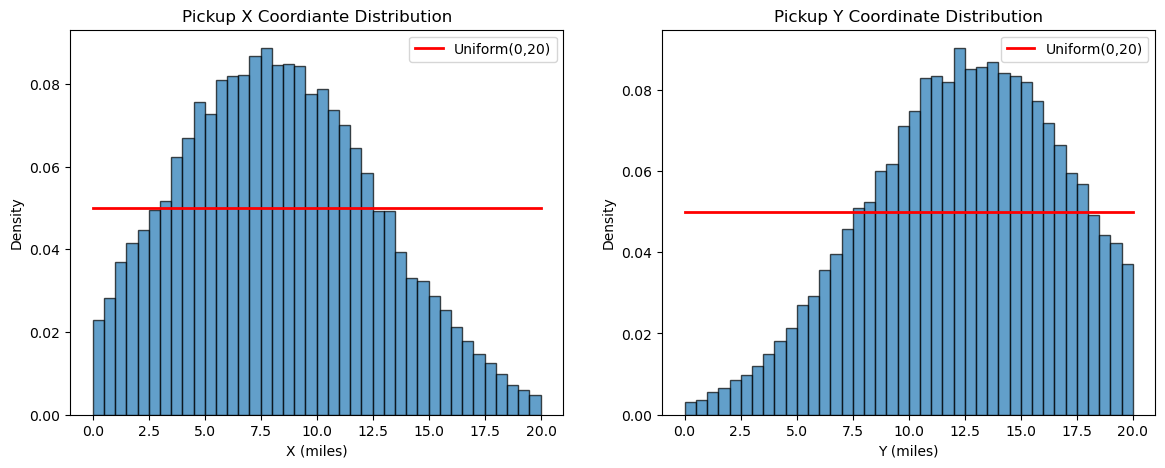

In [40]:
def parse_location(loc_str):
    if pd.isna(loc_str):
        return None, None
    coords = loc_str.strip('()').split(',')
    return float(coords[0]), float(coords[1])

df_rider['pickup_x'] = df_rider['pickup_location'].apply(lambda x: parse_location(x)[0])
df_rider['pickup_y'] = df_rider['pickup_location'].apply(lambda x: parse_location(x)[1])
df_rider['dropoff_x'] = df_rider['dropoff_location'].apply(lambda x: parse_location(x)[0])
df_rider['dropoff_y'] = df_rider['dropoff_location'].apply(lambda x: parse_location(x)[1])
df_driver['init_x'] = df_driver['initial_location'].apply(lambda x: parse_location(x)[0])
df_driver['init_y'] = df_driver['initial_location'].apply(lambda x: parse_location(x)[1])



x = df_rider['pickup_x'].dropna()
y = df_rider['pickup_y'].dropna()

fig, axs = plt.subplots(1,2, figsize=(14,5))

axs[0].hist(x,bins=40,density=True,alpha=0.7,edgecolor='black')
xx = np.linspace(0,20,200)
axs[0].plot(xx, stats.uniform.pdf(xx,loc=0,scale=20),
           'r-', linewidth=2, label='Uniform(0,20)')
axs[0].set_title('Pickup X Coordiante Distribution')
axs[0].set_xlabel('X (miles)')
axs[0].set_ylabel('Density')
axs[0].legend()

axs[1].hist(y,bins=40,density=True,alpha=0.7,edgecolor='black')
yy = np.linspace(0,20,200)
axs[1].plot(yy, stats.uniform.pdf(yy,loc=0,scale=20),
           'r-', linewidth=2, label='Uniform(0,20)')
axs[1].set_title('Pickup Y Coordinate Distribution')
axs[1].set_xlabel('Y (miles)')
axs[1].set_ylabel('Density')
axs[1].legend()

#plt.tight_layout()
#plt.show()

### 1.3 Trip Distances and Durations

BoxCar assumption: The length of a trip depends on the Euclidean distance between points, d. It is assumed that the average speed is approximately 20mph and the actual trip time is uniformly distributed between (0.8*d/20, 1.2*d/20)

We examined the scalar, actual trip time / (d/20), in the sample data and discovered that it took values (0.7, 1.3), implying that actual trip time in the sample data cannot be perturbed by a uniform(0.8, 1.2) random variable. We performed a chi-squared test to see if the scalar followed a uniform(0.7, 1.3) distribution.

$H_0$: actual trip time follows a uniform(0.7*d/20, 1.3*d/20) distribution
$H_a$: actual trip time does not follow a uniform(0.7*d/20, 1.3*d/20) distribution

Out test statistic T = 31.23642, T~$\chi^2_{29}$, with P(T>31.23632) = 0.3543648. Therefore, we do not have the evidence from the sample data to reject the null hypothesis that actual trip time follows a uniform(0.7*d/20, 1.3*d/20) distribution.

In [41]:
# now estimating what eh multivariate normal this thingy is 

data = df_rider[['pickup_x', 'pickup_y']].dropna().values

mu = data.mean(axis=0)

Sigma = np.cov(data.T)
#print(mu)
#print(Sigma)

In [42]:
# so weve got this normal looking thing truncated to [0,20] => do rejection sampling to simulate points people request from (will do the same thing later with dropoff locs)
def sample_trunc_mvnorm_fast(mu, Sigma, n, low=0.0, high=20.0, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    mu = np.asarray(mu)
    Sigma = np.asarray(Sigma)

    # Use acceptance estimate to choose a sensible batch size
    z0 = rng.multivariate_normal(mu, Sigma, size=20000)
    acc = np.mean((z0[:,0]>=low)&(z0[:,0]<=high)&(z0[:,1]>=low)&(z0[:,1]<=high))
    acc = max(acc, 1e-3)
    batch = int(np.ceil(n / acc * 1.1))  # 10% cushion

    out = rng.multivariate_normal(mu, Sigma, size=batch)
    ok = (
        (out[:,0]>=low)&(out[:,0]<=high)&
        (out[:,1]>=low)&(out[:,1]<=high)
    )
    out = out[ok]

    # If we still didn't get enough (rare if acc is stable), top up in batches
    while out.shape[0] < n:
        need = n - out.shape[0]
        batch = int(np.ceil(need / acc * 1.1))
        z = rng.multivariate_normal(mu, Sigma, size=batch)
        ok = (
            (z[:,0]>=low)&(z[:,0]<=high)&
            (z[:,1]>=low)&(z[:,1]<=high)
        )
        out = np.vstack([out, z[ok]])

    return out[:n]

samples = sample_trunc_mvnorm_fast(mu, Sigma, n=35000, low=0, high=20)


In [43]:
z = np.random.multivariate_normal(mu, Sigma, size=20000)
acc = np.mean((z[:,0]>=0)&(z[:,0]<=20)&(z[:,1]>=0)&(z[:,1]<=20))
#print("Acceptance rate:", acc) # good to know so we can see that the rejection sampler isnt terribly inefficient
#print(samples) 

In [15]:
#observed = df_rider[['pickup_x','pickup_y']].dropna().values
#simulated = samples  # from your truncated normal sampler

#fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Observed
#axes[0].scatter(observed[:,0], observed[:,1], s=3, alpha=0.1)
#axes[0].set_title("Observed Pickup Locations")
#axes[0].set_xlim(0,20)
#axes[0].set_ylim(0,20)

# Simulated
#axes[1].scatter(simulated[:,0], simulated[:,1], s=3, alpha=0.1, color='orange')
#axes[1].set_title("Simulated Truncated Normal")
#axes[1].set_xlim(0,20)
#axes[1].set_ylim(0,20)

#plt.tight_layout()
#plt.show()
#observed.shape

In [44]:
def fit_mvnorm(points_2d):
    """Fit a (non-truncated) bivariate normal by sample moments.
    For simulation we will *sample then reject* outside the service square to emulate truncation.
    points_2d: array of shape (n,2)
    """
    mu = points_2d.mean(axis=0)
    Sigma = np.cov(points_2d.T) 
    return mu, Sigma

# Fit from observed data
pickup_pts  = df_rider[['pickup_x','pickup_y']].dropna().values
dropoff_pts = df_rider[['dropoff_x','dropoff_y']].dropna().values

driver_initial_pts = df_driver[['init_x', 'init_y']].dropna().values

mu_pick,  Sig_pick  = fit_mvnorm(pickup_pts)
mu_drop,  Sig_drop  = fit_mvnorm(dropoff_pts)
mu_driver, Sig_driver = fit_mvnorm(driver_initial_pts)

#print("Pickup fit  mu:", mu_pick)
#print("Pickup fit  Sigma:\n", Sig_pick)
#print("Dropoff fit mu:", mu_drop)
#print("Dropoff fit Sigma:\n", Sig_drop)
#print("Driver fit mu:", mu_driver)
#print("Driver fit Sigma:\n", Sig_driver)


## 1.4 Summary of Data vs Spec Parameters

| Parameter | BoxCar Assumption | Empirical (Data) |
|---|---|---|
| Driver arrival rate | 3/hr | **4.74/hr** |
| Driver shift length | U[5, 8] hrs | **U[6, 8] hrs** |
| Driver initial location | Uniform | Truncated Bivariate Normal |
| Rider arrival rate | 30/hr | **34.6/hr** |
| Rider locations | Uniform | Truncated Bivariate Normal |
| Rider patience | Exp(5/hr) | ~0.81% abandon (consistent) |
| Avg trip distance | ~9.4 mi (theory for 20×20) | **8.16 mi** |
| Avg waiting time | — | **14.2 min** |
| Actual trip duration perturbation | Uniform(0.8, 1.2) | Uniform(0.7, 1.3)|

---
# 2. Simulation Model

We implement a discrete-event simulation engine with the following features:

- The simulation runs for 200 hours
- Rider arrivals with exponential inter-arrival times and exponential patience (abandonment if unmatched)
- Driver arrivals with exponential inter-arrival and uniform shift lengths; drivers go offline after their shift (finishing any current trip first)
- Closest-driver matching triggered whenever a new rider arrives or a driver becomes idle. Candidates include both idle and repositioning drivers (who are interruptible)
- Two-phase trips: pickup travel (driver→origin) then trip travel (origin→destination), both with travel time ~ U[0.8$\mu$, 1.2$\mu$] where $\mu$= distance/20 mph
- Fare: £3 base + £2/mile (origin→destination); Fuel: £0.20/mile for ALL miles driven
- Warm-up period to reach steady state (24 hours), and **multiple replications (100) for statistical validity

The logic of the model works as follows:

In [17]:
display(Image(filename='boxcar_flow.png'))

FileNotFoundError: [Errno 2] No such file or directory: 'boxcar_flow.png'

In [45]:
class BoxCarSimulation:
    """
    Discrete-event simulation of the BoxCar ridesharing system.
    Uses a heap-based event list with tiebreaker counter.
    """

    def __init__(self, params, seed=None):
        self.p = params
        self.seed = seed
        self.rng = np.random.default_rng(seed)
        self._pool_pick = None
        self._pool_drop = None
        self._pool_drv  = None
        self._k_pick = 0
        self._k_drop = 0
        self._k_drv  = 0
        self.idle_policy  = self.p.get("idle_policy", None)

    def run(self):
        """Execute one simulation run. Returns a metrics dict."""
        if self.seed is not None:
            random.seed(self.seed)
            # Keep NumPy RNG in sync for reproducibility
            self.rng = np.random.default_rng(self.seed)

        # State variables
        self.clock = 0.0
        self.event_list = []
        self.event_counter = 0

        self.idle_drivers = []
        self.repositioning_drivers = [] 
        self.waiting_riders = []    # list of (rider_dict, patience_deadline)
        self.all_drivers = []

        # Metrics
        self.total_riders = 0
        self.abandonments_list = []  # store times for warm-up-consistent rates
        self.waiting_times = []
        self.driver_records = []

        # Schedule first arrivals
        self._schedule("RIDER_ARRIVAL",
                       self.clock + random.expovariate(self.p["rider_rate"]))
        self._schedule("DRIVER_ARRIVAL",
                       self.clock + random.expovariate(self.p["driver_rate"]))

        # Main loop
        while self.event_list:
            _, _, event = heapq.heappop(self.event_list)
            if event["time"] > self.p["sim_duration"]:
                break
            self.clock = event["time"]

            handler = {
                "RIDER_ARRIVAL":        self._handle_rider_arrival,
                "DRIVER_ARRIVAL":       self._handle_driver_arrival,
                "RIDER_ABANDON":        self._handle_rider_abandon,
                "PICKUP_COMPLETE":      self._handle_pickup_complete,
                "DROPOFF":              self._handle_dropoff,
                "DRIVER_GO_OFFLINE":    self._handle_driver_offline,
                "REPOSITION_COMPLETE":  self._handle_reposition_complete,
            }.get(event["type"])

            if handler:
                handler(event)

        return self._compile_metrics(self.p["warm_up"])

    # --- Event scheduling ---

    def _schedule(self, etype, time, data=None):
        self.event_counter += 1
        event = {"type": etype, "time": time, "data": data or {}}
        heapq.heappush(self.event_list, (time, self.event_counter, event))

    # --- Matching logic ---

    def _try_match(self):
        """Match waiting riders with available drivers.
        Available = idle drivers + repositioning drivers (interruptible).
        Closest-driver-to-rider matching; FIFO on rider side."""
        matched_any = True
        while matched_any:
            matched_any = False
            # Clean up abandoned riders
            self.waiting_riders = [(r, d) for r, d in self.waiting_riders
                                   if r["status"] == "waiting"]
            if not self.waiting_riders or not self.idle_drivers:
                break

            rider, deadline = self.waiting_riders[0]
            if self.clock > deadline:
                self.waiting_riders.pop(0)
                continue

            # Build candidate pool
            candidates = []
            for i, d in enumerate(self.idle_drivers):
                candidates.append(("idle", i, d, d["location"]))
            for i, d in enumerate(self.repositioning_drivers):
                loc = self._estimate_reposition_loc(d)
                candidates.append(("repositioning", i, d, loc))

            if not candidates:
                break

            # Find closest idle driver to rider origin
            max_busy_time_idle_drivers_c = max(candidates,
                                            key=lambda c: (c[2]["busy_time"] / (self.clock - c[2]["arrival_time"] + 0.1)))
            
            max_busy_time_idle_drivers = max_busy_time_idle_drivers_c[2]["busy_time"] / (self.clock - max_busy_time_idle_drivers_c[2]["arrival_time"] + 0.1)
                                            
            if self.p["weight_distance_by_utilization"] is True and max_busy_time_idle_drivers > 0.0:
                best =  min(candidates,
                            key=lambda c: ((c[2]["busy_time"] / (self.clock - c[2]["arrival_time"] + 0.1)) / max_busy_time_idle_drivers) * self._dist(
                            c[3], rider["origin"]))
                pool_type, pool_idx, driver, driver_loc = best
            else:
                # Closest candidate to rider origin
                best = min(candidates, key=lambda c: self._dist(c[3], rider["origin"]))
                pool_type, pool_idx, driver, driver_loc = best
                            
            if pool_type == "idle":
                self.idle_drivers.pop(pool_idx)
            else:
                self.repositioning_drivers.pop(pool_idx)
                self._cancel_reposition(driver)
    
            self.waiting_riders.pop(0)

            # Update our driver/rider status 
            rider["status"] = "matched"
            driver["status"] = "driving_to_pickup"
            driver["location"] = driver_loc

            # Compute pickup travel time
            d_pickup = self._dist(driver["location"], rider["origin"])
            mu_pickup = d_pickup / self.p["speed"]
            pickup_time = random.uniform(self.p["trip_scalar_min"] * mu_pickup, self.p["trip_scalar_max"] * mu_pickup) if mu_pickup > 0 else 0.0

            rider["match_time"] = self.clock
            rider["pickup_distance"] = d_pickup

            self._schedule("PICKUP_COMPLETE", self.clock + pickup_time,
                           {"rider": rider, "driver": driver})
            matched_any = True
    

    def _estimate_reposition_loc(self, driver):
        """Linearly interpolate the repositioning driver's current position."""
        t_start = driver.get("reposition_start_time", self.clock)
        t_end   = driver.get("reposition_end_time", self.clock)
        start   = driver.get("reposition_start_loc", driver["location"])
        target  = driver.get("reposition_target", driver["location"])
        if t_end <= t_start:
            return target
        frac = min(1.0, (self.clock - t_start) / (t_end - t_start))
        return (start[0] + frac*(target[0]-start[0]),
                start[1] + frac*(target[1]-start[1]))

    def _cancel_reposition(self, driver):
        """Cancel in-progress reposition; refund un-travelled fuel."""
        start  = driver.get("reposition_start_loc", driver["location"])
        target = driver.get("reposition_target", driver["location"])
        current = self._estimate_reposition_loc(driver)
        full_dist   = self._dist(start, target)
        actual_dist = self._dist(start, current)
        refund = max(0.0, full_dist - actual_dist)
        driver["fuel_cost"]  -= self.p["fuel_per_mile"] * refund
        driver["total_miles"] -= refund
        for key in ("reposition_target","reposition_start_loc",
                    "reposition_start_time","reposition_end_time"):
            driver.pop(key, None)

# --- Event handlers ---
    def _handle_rider_arrival(self, event):
        self.total_riders += 1
        rider = {
            "id": self.total_riders,
            "arrival_time": self.clock,
            "origin": self._draw_pickup(),
            "destination": self._draw_dropoff(),
            "status": "waiting",
            "match_time": None,
            "pickup_distance": 0,
        }
        patience = random.expovariate(self.p["patience_rate"])
        deadline = self.clock + patience
        self.waiting_riders.append((rider, deadline))
        self._schedule("RIDER_ABANDON", deadline, {"rider": rider})
        self._schedule("RIDER_ARRIVAL",
                       self.clock + random.expovariate(self.p["rider_rate"]))
        self._try_match()

    def _handle_rider_abandon(self, event):
        rider = event["data"]["rider"]
        if rider["status"] == "waiting":
            rider["status"] = "abandoned"
            self.abandonments_list.append(self.clock)

    def _handle_driver_arrival(self, event):
        driver = {
            "id": len(self.all_drivers) + 1,
            "arrival_time": self.clock,
            "location": self._draw_driver_loc(),
            "status": "idle",
            "earnings": 0.0,
            "fuel_cost": 0.0,
            "trips_completed": 0,
            "total_miles": 0.0,
            "busy_time": 0.0,
        }
        shift = random.uniform(self.p["shift_min"], self.p["shift_max"])
        driver["offline_deadline"] = self.clock + shift
        self._schedule("DRIVER_GO_OFFLINE", driver["offline_deadline"],
                       {"driver": driver})
        self.all_drivers.append(driver)
        self.idle_drivers.append(driver)
        self._schedule("DRIVER_ARRIVAL",
                       self.clock + random.expovariate(self.p["driver_rate"]))
        self._try_match()

    def _handle_pickup_complete(self, event):
        rider  = event["data"]["rider"]
        driver = event["data"]["driver"]
        wait = self.clock - rider["arrival_time"]
        self.waiting_times.append((rider["arrival_time"], wait))
        driver["location"] = rider["origin"]
        d_pickup = rider["pickup_distance"]
        driver["fuel_cost"]  += self.p["fuel_per_mile"] * d_pickup
        driver["total_miles"] += d_pickup
        d_trip = self._dist(rider["origin"], rider["destination"])
        mu_trip = d_trip / self.p["speed"]
        trip_time = random.uniform(0.8*mu_trip, 1.2*mu_trip) if mu_trip > 0 else 0.0
        rider["status"]  = "in_trip"
        driver["status"] = "in_trip"
        self._schedule("DROPOFF", self.clock + trip_time,
                       {"rider": rider, "driver": driver,
                        "trip_distance": d_trip,
                        "pickup_start": rider["match_time"]})

    def _handle_dropoff(self, event):
        rider  = event["data"]["rider"]
        driver = event["data"]["driver"]
        d_trip = event["data"]["trip_distance"]
        pickup_start = event["data"]["pickup_start"]
        rider["status"] = "dropped_off"
        fare = self.p["base_fare"] + self.p["per_mile_fare"] * d_trip
        driver["earnings"]  += fare
        driver["fuel_cost"] += self.p["fuel_per_mile"] * d_trip
        driver["total_miles"] += d_trip
        driver["trips_completed"] += 1
        driver["location"] = rider["destination"]
        if pickup_start is not None:
            driver["busy_time"] += (self.clock - pickup_start)
        # Check offline
        if self.clock >= driver["offline_deadline"]:
            driver["status"] = "offline"
            driver["actual_offline"] = self.clock
        else:
            driver["status"] = "idle"
            # Use idle policy if set, otherwise default behaviour
            if self.idle_policy is not None:
                self.idle_policy(self, driver)
            else:
                self.idle_drivers.append(driver)
                self._try_match()

    def _handle_driver_offline(self, event):
        driver = event["data"]["driver"]
        if driver["status"] == "idle":
            if driver in self.idle_drivers:
                self.idle_drivers.remove(driver)
            driver["status"] = "offline"
            driver["actual_offline"] = self.clock
        elif driver["status"] == "repositioning":
            # Remove from repositioning pool, go offline
            if driver in self.repositioning_drivers:
                self.repositioning_drivers.remove(driver)
            self._cancel_reposition(driver)
            driver["status"] = "offline"
            driver["actual_offline"] = self.clock
        elif driver["status"] in ("driving_to_pickup", "in_trip"):
            pass  # Will go offline after current trip (checked in dropoff)
        else:
            driver["status"] = "offline"
            driver["actual_offline"] = self.clock

    def _handle_reposition_complete(self, event):
        driver = event["data"]["driver"]
        target = event["data"]["target"]
        # Guard: if driver was interrupted, skip
        if driver["status"] != "repositioning":
            return
        driver["location"] = target
        driver["status"] = "idle"
        if driver in self.repositioning_drivers:
            self.repositioning_drivers.remove(driver)
        for key in ("reposition_target","reposition_start_loc",
                    "reposition_start_time","reposition_end_time"):
            driver.pop(key, None)
        self.idle_drivers.append(driver)
        self._try_match()

    # --- Spatial drawing ---
    def _draw_pickup(self):
        R = self.p["region_size"]
        if not self.p.get("calibrated_spatial", False):
            return (random.uniform(0, R), random.uniform(0, R))
        if self._pool_pick is None or self._k_pick >= len(self._pool_pick):
            self._pool_pick = sample_trunc_mvnorm_fast(
                self.p["mu_pick"], self.p["Sig_pick"],
                n=50000, low=0.0, high=R, rng=self.rng)
            self._k_pick = 0
        pt = self._pool_pick[self._k_pick]; self._k_pick += 1
        return (float(pt[0]), float(pt[1]))

    def _draw_dropoff(self):
        R = self.p["region_size"]
        if not self.p.get("calibrated_spatial", False):
            return (random.uniform(0, R), random.uniform(0, R))
        if self._pool_drop is None or self._k_drop >= len(self._pool_drop):
            self._pool_drop = sample_trunc_mvnorm_fast(
                self.p["mu_drop"], self.p["Sig_drop"],
                n=50000, low=0.0, high=R, rng=self.rng)
            self._k_drop = 0
        pt = self._pool_drop[self._k_drop]; self._k_drop += 1
        return (float(pt[0]), float(pt[1]))

    def _draw_driver_loc(self):
        R = self.p["region_size"]
        if not self.p.get("calibrated_spatial", False):
            return (random.uniform(0,R), random.uniform(0,R))
        mu  = self.p.get("mu_driver", self.p["mu_pick"])
        Sig = self.p.get("Sig_driver", self.p["Sig_pick"])
        if self._pool_drv is None or self._k_drv >= len(self._pool_drv):
            self._pool_drv = sample_trunc_mvnorm_fast(
                mu, Sig, n=10000, low=0.0, high=R, rng=self.rng)
            self._k_drv = 0
        pt = self._pool_drv[self._k_drv]; self._k_drv += 1
        return (float(pt[0]), float(pt[1]))


    @staticmethod
    def _dist(p1, p2):
        return math.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)

    def _compile_metrics(self, warm_up):
        wt = [w for (t, w) in self.waiting_times if t >= warm_up]
        ab_post = sum(1 for t in self.abandonments_list if t >= warm_up)

        driver_earnings, driver_net, driver_hourly = [], [], []
        driver_util, driver_trips = [], []

        for d in self.all_drivers:
            if d["arrival_time"] < warm_up:
                continue
            actual_off = d.get("actual_offline", self.p["sim_duration"])
            shift_dur = actual_off - d["arrival_time"]
            if shift_dur <= 0:
                continue

            net = d["earnings"] - d["fuel_cost"]
            driver_earnings.append(d["earnings"])
            driver_net.append(net)
            driver_hourly.append(net / shift_dur)
            driver_util.append(d["busy_time"] / shift_dur)
            driver_trips.append(d["trips_completed"])

        return {
            "avg_wait": statistics.mean(wt) if wt else 0,
            "median_wait": statistics.median(wt) if wt else 0,
            "p90_wait": float(np.percentile(wt, 90)) if wt else 0,
            "total_served": len(wt),
            "total_abandoned": ab_post,
            "abandon_rate": ab_post / (len(wt) + ab_post) if (len(wt) + ab_post) > 0 else 0,
            "avg_gross_earning": statistics.mean(driver_earnings) if driver_earnings else 0,
            "avg_net_earning": statistics.mean(driver_net) if driver_net else 0,
            "avg_hourly_net": statistics.mean(driver_hourly) if driver_hourly else 0,
            "std_hourly_net": statistics.stdev(driver_hourly) if len(driver_hourly) > 1 else 0,
            "avg_utilisation": statistics.mean(driver_util) if driver_util else 0,
            "avg_trips_per_driver": statistics.mean(driver_trips) if driver_trips else 0,
            "num_drivers": len(driver_earnings),
            "waiting_times_raw": wt,
            "driver_hourly_raw": driver_hourly,
        }


def print_metrics(m, label=""):
    print(f"{'='*55}")
    if label:
        print(f"  {label}")
        print(f"{'='*55}")
    print(f"  Riders served:           {m['total_served']}")
    print(f"  Riders abandoned:        {m['total_abandoned']}")
    print(f"  Abandonment rate:        {m['abandon_rate']*100:.2f}%")
    print(f"  Avg wait time:           {m['avg_wait']*60:.1f} min")
    print(f"  Median wait time:        {m['median_wait']*60:.1f} min")
    print(f"  90th pctile wait:        {m['p90_wait']*60:.1f} min")
    print(f"  ---")
    print(f"  Drivers (post warm-up):  {m['num_drivers']}")
    print(f"  Avg gross earning:       £{m['avg_gross_earning']:.2f}")
    print(f"  Avg net earning:         £{m['avg_net_earning']:.2f}")
    print(f"  Avg hourly net:          £{m['avg_hourly_net']:.2f}/hr")
    print(f"  Std hourly net:          £{m['std_hourly_net']:.2f}/hr")
    print(f"  Avg utilisation:         {m['avg_utilisation']*100:.1f}%")
    print(f"  Avg trips/driver:        {m['avg_trips_per_driver']:.1f}")


def average_metrics(results):
    keys = ["avg_wait", "median_wait", "p90_wait", "total_served",
            "total_abandoned", "abandon_rate", "avg_gross_earning",
            "avg_net_earning", "avg_hourly_net", "std_hourly_net",
            "avg_utilisation", "avg_trips_per_driver", "num_drivers"]
    avg = {k: statistics.mean([r[k] for r in results]) for k in keys}
    avg["waiting_times_raw"] = []
    avg["driver_hourly_raw"] = []
    return avg


#print("Simulation engine ready.")

---
## 3. Examining baseline and calibrated scenario

In [46]:
baseline_params = {
    "rider_rate": 30, "driver_rate": 3, "patience_rate": 5,
    "shift_min": 5, "shift_max": 8,
    "trip_scalar_min": 0.8, "trip_scalar_max": 1.2,
    "speed": 20, "base_fare": 3, "per_mile_fare": 2,
    "fuel_per_mile": 0.20, "region_size": 20,
    "sim_duration": 200, "warm_up": 24, 
    "weight_distance_by_utilization": False
}

NUM_REPS = 100 # Might want to increase this, 5 isnt necessarily a large number of total simulations 
#print(f"Running {NUM_REPS} replications of {baseline_params['sim_duration']}h ")
#print(f"(warm-up: {baseline_params['warm_up']}h)...")

baseline_results = []
for rep in range(NUM_REPS):
    sim = BoxCarSimulation(baseline_params, seed=42 + rep)
    m = sim.run()
    baseline_results.append(m)
#    print(f"  Rep {rep+1}: served={m['total_served']}, "
#          f"abandoned={m['total_abandoned']}, "
#          f"avg_wait={m['avg_wait']*60:.1f}min, "
#          f"abandon={m['abandon_rate']*100:.1f}%")

baseline_avg = average_metrics(baseline_results)
#print_metrics(baseline_avg, "BASELINE AVERAGE (BoxCar spec params)")

In [47]:
# scenario where i fix the spatial distributions
calib_params = dict(baseline_params)  # copy
calib_params["calibrated_spatial"] = True
calib_params["mu_pick"]  = mu_pick
calib_params["Sig_pick"] = Sig_pick
calib_params["mu_drop"]  = mu_drop
calib_params["Sig_drop"] = Sig_drop
calib_params["mu_driver"] = mu_driver
calib_params["Sig_driver"] = Sig_driver

In [48]:
# Data-calibrated scenario: calibrate rates/shifts to observed data AND use fitted spatial distributions
calibrated_params = dict(baseline_params)
calibrated_params.update({
    "rider_rate": 34.6,      # from data analysis
    "driver_rate": 4.74,     # from data analysis
    "shift_min": 6,
    "shift_max": 8,
    "trip_scalar_min": 0.7,
    "trip_scalar_max": 1.3,
    # spatial calibration (pickups + dropoffs)
    "calibrated_spatial": True,
    "mu_pick":  mu_pick,
    "Sig_pick": Sig_pick,
    "mu_drop":  mu_drop,
    "Sig_drop": Sig_drop,
    "mu_driver": mu_driver,
    "Sig_driver": Sig_driver
})

#print("Key differences from baseline:")
#print(f"  Rider rate: 30 -> {calibrated_params['rider_rate']}/hr")
#print(f"  Driver rate: 3 -> {calibrated_params['driver_rate']}/hr")
#print(f"  Shift range: U[5,8] -> U[{calibrated_params['shift_min']},{calibrated_params['shift_max']}]")
#print("  Spatial: uniform -> truncated bivariate normal (moment-fit + rejection)")


In [49]:
calibrated_results = []

for rep in range(NUM_REPS):
    sim = BoxCarSimulation(calibrated_params, seed = 42 + rep)
    calibrated_results.append(sim.run())
calibrated_avg = average_metrics(calibrated_results)
#print_metrics(calibrated_avg, "CALIBRATED DATA")

In [50]:
scenarios_baseline_calibrated = {
    "Baseline (spec)": baseline_avg,
    "Calibrated (data)": calibrated_avg
}

header = f"{'Scenario':<24} {'Riders_served':>6} {'Abandon%':>10} {'AvgWait':>10} {'P90Wait':>10} "
print(header)
print("-" * len(header))
for name, m in scenarios_baseline_calibrated.items():
    print(f"{name:<24}"
          f"    {m['total_served']:>7.2f}  "
          f"   {m['abandon_rate']*100:>7.2f}% "
          f"{m['avg_wait']*60:>9.1f}m "
          f"{m['p90_wait']*60:>9.1f}m "
    )


Scenario                 Riders_served   Abandon%    AvgWait    P90Wait 
------------------------------------------------------------------------
Baseline (spec)             3596.34       31.66%      31.2m      54.7m 
Calibrated (data)           6027.66        1.01%      12.4m      25.4m 


**Description of results**

In [51]:
header = f"{'Scenario':<22}  {'Drivers':>10} {'£/hr net':>10} {'  £/hr net std':>6} {'Util%':>8} {'  Avg Trips / driver':>6}"
print(header)
print("-" * len(header))
for name, m in scenarios_baseline_calibrated.items():
    print(f"{name:<24}"
          f"{m['num_drivers']:>9.1f}"
          f"  {m['avg_hourly_net']:>9.2f} "
          f"   {m['std_hourly_net']:>9.2f}"
          f"    {m['avg_utilisation']*100:>7.1f}% "
          f"      {m['avg_trips_per_driver']:>5.1f}")

Scenario                   Drivers   £/hr net   £/hr net std    Util%   Avg Trips / driver
------------------------------------------------------------------------------------------
Baseline (spec)             529.8      19.04         3.17       93.9%         6.6
Calibrated (data)           835.9      15.30         5.12       56.9%         7.1


Examining the above output, the rider abandon percentage appears implausibly high for the baseline secnario, indicating that either one or both of the driver and rider inter-arrival times assumptions provided by BoxCar do not accurately represent the underlying system. This is clearly a concern we should report back to BoxCar. In order to proceed to testing possible improvements whilst retaining the possiblity that BoxCar's remaining assumptions are sound, we opted to adjust the driver inter-arrival time and the rider inter-arrival time assumptions to match those estimated with the cut of operational data.

In [52]:
baseline_adjusted_params = dict(baseline_params)
baseline_adjusted_params.update({
    "rider_rate": 34.6,      # from data analysis
    "driver_rate": 4.74
})

baseline_adjusted_results = []

for rep in range(NUM_REPS):
    sim = BoxCarSimulation(baseline_adjusted_params, seed = 42 + rep)
    baseline_adjusted_results.append(sim.run())
baseline_adjusted_avg = average_metrics(baseline_adjusted_results)


In [53]:
scenarios_baseline_baseline_adjusted = {
    "Baseline (spec)": baseline_avg,
    "Baseline adjusted (data)": baseline_adjusted_avg
}

header = f"{'Scenario':<24} {'Riders_served':>6} {'Abandon%':>10} {'AvgWait':>10} {'P90Wait':>10} "
print(header)
print("-" * len(header))
for name, m in scenarios_baseline_baseline_adjusted.items():
    print(f"{name:<24}"
          f"    {m['total_served']:>7.2f}  "
          f"   {m['abandon_rate']*100:>7.2f}% "
          f"{m['avg_wait']*60:>9.1f}m "
          f"{m['p90_wait']*60:>9.1f}m "
    )

Scenario                 Riders_served   Abandon%    AvgWait    P90Wait 
------------------------------------------------------------------------
Baseline (spec)             3596.34       31.66%      31.2m      54.7m 
Baseline adjusted (data)    5477.19        9.89%      20.3m      43.5m 


In [54]:
header = f"{'Scenario':<22}  {'Drivers':>10} {'£/hr net':>10} {'  £/hr net std':>6} {'Util%':>8} {'  Avg Trips / driver':>6}"
print(header)
print("-" * len(header))
for name, m in scenarios_baseline_baseline_adjusted.items():
    print(f"{name:<24}"
          f"{m['num_drivers']:>9.1f}"
          f"  {m['avg_hourly_net']:>9.2f} "
          f"   {m['std_hourly_net']:>9.2f}"
          f"    {m['avg_utilisation']*100:>7.1f}% "
          f"      {m['avg_trips_per_driver']:>5.1f}")

Scenario                   Drivers   £/hr net   £/hr net std    Util%   Avg Trips / driver
------------------------------------------------------------------------------------------
Baseline (spec)             529.8      19.04         3.17       93.9%         6.6
Baseline adjusted (data)    833.1      19.33         3.72       79.7%         6.4


As can be seen from the above comparison, making this change reduces the rider abandonment percentage substantially.

In the remainder of this report, 'Baseline adjusted (data)' refers to the spec assumptions with the driver and rider inter-arrival times changed to match those calibrated from the cut of data.


---
# Part 4: Improvement Scenarios 

We test four interventions to improve rider satisfaction while monitoring the trade-off with driver earnings:

1. **More drivers** — Increase driver arrival rate to 6/hr
2. **Longer shifts** — Extend shift range to U[7, 10] hours
3. **Weighted distance calc** - when matching a rider to a driver, we weight the euclidean distance between them by the relative proportion of each driver's shift that they've been non-idle
4. **Adaptive Ellipse ring idle policy** - idle drivers move to a coordinate on the map that's more likely to be closer to incoming rider locations

To provide clarity on what improvements 3. and 4. entail:

For improvement 3, at time $t$ in the simulation let $I_{t}$ be the set of idle drivers, and $B_{t,i}$,  $i \in I_{t}$, be their proportional busy time (time they were driving a passenger / total time they've been on shift at time $t$), and let $K_{t}$ be the max{$B_{t, i}$, $i \in I_{t}$}, and let $d_{i}$, $i \in I_{t}$ = the distance between some rider freshly requesting a taxi at time $t$ and the idle drivers at time $t$. Then the weighted distance between said rider and driver $i$ is given by, $d_{i}$ * $B_{t, i}$ / $K_{t}$, for all $i \in I_{t}$. 

For improvement 4, when a driver finishes a trip, count n_active = number of idle drivers + repositioning drivers; Compute n_active evenly-spaced homes around the 1-sd Mahalanobis ellipse of the pickup distribution (determined by BoxCar assumptions in Baseline adjusted case and by the sample data in the Calibrated case); assign the driver to the closest available home slot; if the driver's locations is already within 0.25 miles of the slot, the driver stays put and does not waste fuel; otherwise, begin the driver beings repositioning, but remain **interruptible** (if a rider request arrives and this driver is closest, they divert mid-journey to the pickup instead)

To help visualise what improvement 4 looks like when implemented (for the calibrated data)

In [55]:
# Adaptive ellipse ring idle policy
def ellipse_home(mu, Sigma, theta, c=1.0):
    
    mu = np.asarray(mu, dtype=float)
    L = np.linalg.cholesky(np.asarray(Sigma, dtype=float))
    u = np.array([math.cos(theta), math.sin(theta)])
    x = mu + c * (L @ u)
    return (float(x[0]), float(x[1]))

def scale_to_box(mu, pt, box_min=0.0, box_max=20.0):
    
    mu = np.asarray(mu, dtype=float)
    pt = np.asarray(pt, dtype=float)
    direction = pt - mu
    t = 1.0
    for i in range(2):
        if direction[i] > 0 and pt[i] > box_max:
            t = min(t, (box_max - mu[i]) / direction[i])
        elif direction[i] < 0 and pt[i] < box_min:
            t = min(t, (box_min - mu[i]) / direction[i])
    result = mu + t * direction
    return (float(np.clip(result[0], box_min, box_max)),
            float(np.clip(result[1], box_min, box_max)))


def make_adaptive_ring_idle_policy(mu, Sigma, c=1.0,
                                    box_min=0.0, box_max=20.0, tol=0.25):
  
    mu_arr = (float(mu[0]), float(mu[1]))
    Sigma_arr = np.asarray(Sigma, dtype=float)

    def _compute_homes(n):
        if n == 0:
            return []
        homes = []
        for i in range(n):
            theta = 2 * math.pi * i / n
            h = ellipse_home(mu_arr, Sigma_arr, theta, c=c)
            h = scale_to_box(mu_arr, h, box_min=box_min, box_max=box_max)
            homes.append(h)
        return homes

    def idle_policy(sim, driver):
        # n_active = everyone who will be idle/repositioning including this driver
        n_active = len(sim.idle_drivers) + len(sim.repositioning_drivers) + 1

        homes = _compute_homes(n_active)
        if not homes:
            sim.idle_drivers.append(driver)
            sim._try_match()
            return

        # collect the claimed positions of active drivers
        claimed = set()
        for d in sim.idle_drivers:
            # find home this idle driver is closest to
            best_h = min(range(len(homes)),
                         key=lambda j: sim._dist(d["location"], homes[j]))
            claimed.add(best_h)
        for d in sim.repositioning_drivers:
            tgt = d.get("reposition_target", d["location"])
            best_h = min(range(len(homes)),
                         key=lambda j: sim._dist(tgt, homes[j]))
            claimed.add(best_h)

        # assign driver to return to the closest unclaimed home 
        unclaimed = [j for j in range(len(homes)) if j not in claimed]
        if not unclaimed:
            # all the slots are claimed s just go to the nearest 
            unclaimed = list(range(len(homes)))

        best_j = min(unclaimed,
                     key=lambda j: sim._dist(driver["location"], homes[j]))
        home = homes[best_j]

        d = sim._dist(driver["location"], home)
        if d <= tol:
            sim.idle_drivers.append(driver)
            sim._try_match()
            return

        # interruptible reposition when driving to home 
        mu_t = d / sim.p["speed"]
        tmove = random.uniform(0.8 * mu_t, 1.2 * mu_t)
        driver["fuel_cost"]  += sim.p["fuel_per_mile"] * d
        driver["total_miles"] += d
        driver["status"] = "repositioning"
        driver["reposition_target"]     = home
        driver["reposition_start_loc"]  = driver["location"]
        driver["reposition_start_time"] = sim.clock
        driver["reposition_end_time"]   = sim.clock + tmove
        sim.repositioning_drivers.append(driver)
        sim._schedule("REPOSITION_COMPLETE", sim.clock + tmove,
                       {"driver": driver, "target": home})

    return idle_policy


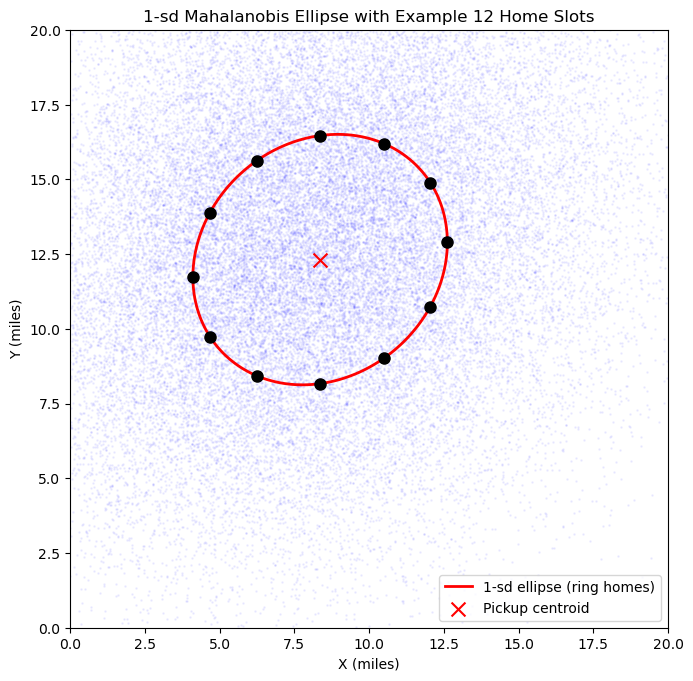

In [56]:
# Visualise the 1-sd ellipse to understand where drivers reposition to
theta_range = np.linspace(0, 2*np.pi, 200)
ellipse_pts = np.array([ellipse_home(mu_pick, Sig_pick, th, c=1.0) for th in theta_range])
ellipse_clipped = np.array([scale_to_box(mu_pick, p) for p in ellipse_pts])

fig, ax = plt.subplots(figsize=(7,7))
ax.plot(ellipse_clipped[:,0], ellipse_clipped[:,1], 'r-', lw=2, label='1-sd ellipse (ring homes)')
ax.scatter(*mu_pick, color='red', s=100, zorder=5, marker='x', label='Pickup centroid')
# example homes for N=12 cars 
for i in range(12):
    th = 2*np.pi*i/12
    h = ellipse_home(mu_pick, Sig_pick, th, c=1.0)
    h = scale_to_box(mu_pick, h)
    ax.plot(*h, 'ko', ms=8)
# add observed pickups
obs = df_rider[['pickup_x','pickup_y']].dropna().values
ax.scatter(obs[:,0], obs[:,1], s=1, alpha=0.05, color='blue')
ax.set_xlim(0,20); ax.set_ylim(0,20)
ax.set_xlabel('X (miles)'); ax.set_ylabel('Y (miles)')
ax.set_title('1-sd Mahalanobis Ellipse with Example 12 Home Slots')
ax.legend()
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

Baseline adjusted results, figures drawn from across 100 simulations:

In [57]:
# Improvement 1: More drivers
imp1_params_b = baseline_adjusted_params.copy()
imp1_params_b["driver_rate"] = 6

imp1_results_b = []
for rep in range(NUM_REPS):
    sim = BoxCarSimulation(imp1_params_b, seed=42 + rep)
    imp1_results_b.append(sim.run())
imp1_avg_b = average_metrics(imp1_results_b)
#print_metrics(imp1_avg_b, "IMPROVEMENT 1: More drivers (6/hr) - baseline params")

In [58]:
# Improvement 2: Longer shifts

imp2_params_b = baseline_adjusted_params.copy()
imp2_params_b["shift_min"] = 7
imp2_params_b["shift_max"] = 10

imp2_results_b = []
for rep in range(NUM_REPS):
    sim = BoxCarSimulation(imp2_params_b, seed=42 + rep)
    imp2_results_b.append(sim.run())
imp2_avg_b = average_metrics(imp2_results_b)
#print_metrics(imp2_avg_b, "IMPROVEMENT 2: Longer shifts U[7,10] - baseline params")

In [59]:
# Improvement 3, weight distance by driver utilization
"weight_distance_by_utilization"

imp3_params_b = baseline_adjusted_params.copy()
imp3_params_b["weight_distance_by_utilization"] = True

imp3_results_b = []
for rep in range(NUM_REPS):
    sim = BoxCarSimulation(imp3_params_b, seed=42 + rep)
    imp3_results_b.append(sim.run())
imp3_avg_b = average_metrics(imp3_results_b)

In [60]:
# Improvement 4, Adaptive Ring Policy
ring_params = dict(baseline_adjusted_params)
ring_params["idle_policy"] = make_adaptive_ring_idle_policy(
    mu=np.array([10, 10]),
    Sigma=np.array([[400/12, 0], [0, 400/12]]),
    c=1.0,
    box_min=0.0, box_max=20.0,
    tol=0.25
)

ring_results_b = []
for rep in range(NUM_REPS):
    sim = BoxCarSimulation(ring_params, seed=42 + rep)
    ring_results_b.append(sim.run())
ring_avg_b = average_metrics(ring_results_b)
#print_metrics(ring_avg_baseline, "IMPROVEMENT 4: Adaptive Ring Policy")

In [61]:
#Improvement 5, weighted distance + adaptive ring policy

wd_ring_params_b = dict(baseline_adjusted_params)
wd_ring_params_b["idle_policy"] = make_adaptive_ring_idle_policy(
    mu=np.array([10, 10]),
    Sigma=np.array([[400/12, 0], [0, 400/12]]),
    c=1.0,
    box_min=0.0, box_max=20.0,
    tol=0.25
)

wd_ring_params_b["weight_distance_by_utilization"] = True

wd_ring_results_b = []
for rep in range(NUM_REPS):
    sim = BoxCarSimulation(wd_ring_params_b, seed=42 + rep)
    wd_ring_results_b.append(sim.run())
wd_ring_avg_b = average_metrics(wd_ring_results_b)
#print_metrics(ring_avg_baseline, "IMPROVEMENT 4: Adaptive Ring Policy")

In [62]:
#Improvement 6, more drivers + adaptive ring policy

md_ring_params_b = dict(baseline_adjusted_params)
md_ring_params_b["idle_policy"] = make_adaptive_ring_idle_policy(
    mu=np.array([10, 10]),
    Sigma=np.array([[400/12, 0], [0, 400/12]]),
    c=1.0,
    box_min=0.0, box_max=20.0,
    tol=0.25
)

md_ring_params_b["driver_rate"] = 6

md_ring_results_b = []
for rep in range(NUM_REPS):
    sim = BoxCarSimulation(md_ring_params_b, seed=42 + rep)
    md_ring_results_b.append(sim.run())
md_ring_avg_b = average_metrics(md_ring_results_b)
#print_metrics(ring_avg_baseline, "IMPROVEMENT 4: Adaptive Ring Policy")

In [63]:
#Improvement 7, more drivers + weighted distance calculation + adaptive ring policy

md_wd_ring_params_b = dict(baseline_adjusted_params)
md_wd_ring_params_b["idle_policy"] = make_adaptive_ring_idle_policy(
    mu=np.array([10, 10]),
    Sigma=np.array([[400/12, 0], [0, 400/12]]),
    c=1.0,
    box_min=0.0, box_max=20.0,
    tol=0.25
)

md_wd_ring_params_b["driver_rate"] = 6

md_wd_ring_params_b["weight_distance_by_utilization"] = True

md_wd_ring_results_b = []
for rep in range(NUM_REPS):
    sim = BoxCarSimulation(md_wd_ring_params_b, seed=42 + rep)
    md_wd_ring_results_b.append(sim.run())
md_wd_ring_avg_b = average_metrics(md_wd_ring_results_b)
#print_metrics(ring_avg_baseline, "IMPROVEMENT 4: Adaptive Ring Policy")

In [64]:
scenarios_baseline = {
    "Baseline adjusted": baseline_adjusted_avg,
    "More drivers (MD) (6/hr)": imp1_avg_b,
    "Longer shifts U[7,10]": imp2_avg_b,
    "Weighted distance (WD)": imp3_avg_b,
    "AdaptiveRingPolicy (ARP)": ring_avg_b,
    "WD + ARP": wd_ring_avg_b,
    "MD + ARP": md_ring_avg_b,
    "MD + WD + ARP": md_wd_ring_avg_b
}

header = f"{'Scenario':<24} {'Riders_served':>6} {'Abandon%':>10} {'AvgWait':>10} {'P90Wait':>10} "
print(header)
print("-" * len(header))
for name, m in scenarios_baseline.items():
    print(f"{name:<24}"
          f"     {m['total_served']:>7.2f}  "
          f"   {m['abandon_rate']*100:>7.2f}% "
          f"{m['avg_wait']*60:>9.1f}m "
          f"{m['p90_wait']*60:>9.1f}m "
    )


Scenario                 Riders_served   Abandon%    AvgWait    P90Wait 
------------------------------------------------------------------------
Baseline adjusted            5477.19        9.89%      20.3m      43.5m 
More drivers (MD) (6/hr)     6007.54        1.24%      11.6m      23.8m 
Longer shifts U[7,10]        6020.92        1.04%      11.1m      22.7m 
Weighted distance (WD)       5436.85       10.54%      23.3m      47.3m 
AdaptiveRingPolicy (ARP)     5502.01        9.66%      13.6m      26.4m 
WD + ARP                     5322.01       12.46%      16.8m      34.3m 
MD + ARP                     5979.82        1.60%       9.9m      18.8m 
MD + WD + ARP                5911.78        2.76%      14.6m      31.7m 


Increasing the number of available drivers or increasing the length of drivers' shifts results in a substantial improvement in rider experience compared with the baseline adjusted scenario. Abandonment drops to ~1%, average rider wait time drops to ~11 minutes, and the 90th percentile of the rider waiting times distribution across simulations drops to ~23 minutes. 

Allowing idle drivers to reposition themselves using the adaptive ring policy achieves comparable improvements in rider waiting times, without the drop in abandonment percentage.

Unsurprisingly given that it's primarily targeted to improve fairness among drivers, weighting the distance calculation results in a degraded rider experience.

On balance, the best rider experience comes from combining the more drivers and adaptive ring policy improvements, leading to an over 50% reduction in rider waiting time compared to the baseline adjusted scenario.

In [65]:
header = f"{'Scenario':<22}  {'Drivers':>10} {'£/hr net':>10} {'  £/hr net std':>6} {'Util%':>8} {'  Avg Trips / driver':>6}"
print(header)
print("-" * len(header))
for name, m in scenarios_baseline.items():
    print(f"{name:<24}"
          f"{m['num_drivers']:>9.1f}"
          f"  {m['avg_hourly_net']:>9.2f} "
          f"   {m['std_hourly_net']:>9.2f}"
          f"    {m['avg_utilisation']*100:>7.1f}% "
          f"      {m['avg_trips_per_driver']:>5.1f}")

Scenario                   Drivers   £/hr net   £/hr net std    Util%   Avg Trips / driver
------------------------------------------------------------------------------------------
Baseline adjusted           833.1      19.33         3.72       79.7%         6.4
More drivers (MD) (6/hr)   1060.8      17.42         4.75       59.0%         5.5
Longer shifts U[7,10]       837.7      17.10         4.42       57.4%         7.0
Weighted distance (WD)      835.5      18.88         3.42       83.3%         6.4
AdaptiveRingPolicy (ARP)    832.0      19.51         3.87       70.6%         6.5
WD + ARP                    838.3      18.45         3.41       72.6%         6.2
MD + ARP                   1050.4      17.11         4.61       57.2%         5.6
MD + WD + ARP              1057.5      16.43         3.59       62.7%         5.5


Intuitively, increasing the number of drivers or the length of drivers' shifts leads to a reduction in driver earnings: more drivers share the same level of demand, which highlights a clear trade‑off between rider satisfaction and driver income.

Weighting the distance calculation results in a slight reduction in hourly earnings but does increase fairness among drivers, indicated by the reduction in the standard deviation of driver eanings across simulations.

Allowing drivers to reposition results in a marginal increase in driver earnings, but a corresponding reduction in fairness among drivers.

Regarding driver rest time, the utilization precentage represents the proportion of their total shifts that drivers were busy across simulations. Our highest utilization percentage comes from the weighted distance scenario, at 83.3%. Considering a stereotypical work day of 8 hours with a 1 hour break for lunch would result in a hypothetical utilization of 87.5%, a utilization of 83.3% does not appear excessive.

None of the tested improvements result in a clear improvemet in driver experience across all relevent metrics. However, the combination of more drivers and the adaptive ring policy which resulted in the best improvement in rider experience, results in the worst driver experience, with both a reduction in average hourly earnings and an increase in unfairness in earnings among drivers.

Key: 

B: Baseline adjusted <br>
MD: More drivers (6/hour) <br>
LS: Longer shifts (U[7, 10]) <br>
WD: Weighted Distance calculation <br>
ARP: Adaptive ring driver relocation policy <br>
Combined: More drivers, weighted distance calculation and adaptive ring driver relocation policy


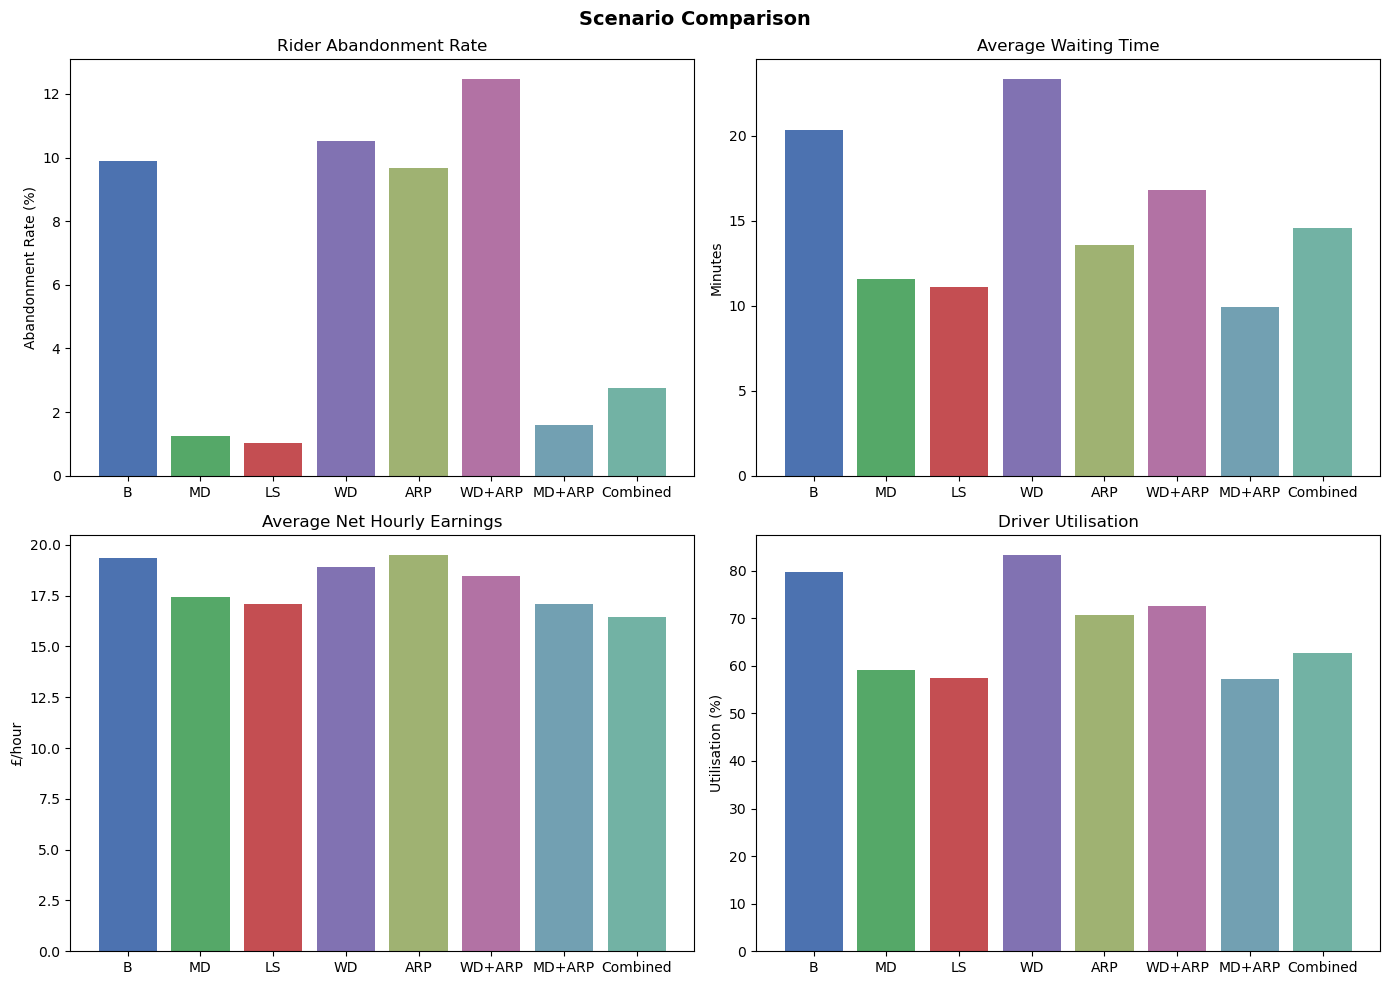

In [66]:
names = list(scenarios_baseline.keys())
short_names = ["B", "MD", "LS", "WD", "ARP", "WD+ARP", "MD+ARP", "Combined"]
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#9FB272", "#B272A4", "#72A0B2", "#72B2A4"]


fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Abandonment rate
vals = [scenarios_baseline[n]["abandon_rate"]*100 for n in names]
axes[0,0].bar(short_names, vals, color=colors)
axes[0,0].set_ylabel("Abandonment Rate (%)")
axes[0,0].set_title("Rider Abandonment Rate")

# Average waiting time
vals = [scenarios_baseline[n]["avg_wait"]*60 for n in names]
axes[0,1].bar(short_names, vals, color=colors)
axes[0,1].set_ylabel("Minutes")
axes[0,1].set_title("Average Waiting Time")

# Hourly net earnings
vals = [scenarios_baseline[n]["avg_hourly_net"] for n in names]
axes[1,0].bar(short_names, vals, color=colors)
axes[1,0].set_ylabel("£/hour")
axes[1,0].set_title("Average Net Hourly Earnings")

# Utilisation
vals = [scenarios_baseline[n]["avg_utilisation"]*100 for n in names]
axes[1,1].bar(short_names, vals, color=colors)
axes[1,1].set_ylabel("Utilisation (%)")
axes[1,1].set_title("Driver Utilisation")

plt.suptitle("Scenario Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

Calibrated data results:

In [67]:
# Improvement 1: More drivers
imp1_params_c = calibrated_params.copy()
imp1_params_c["driver_rate"] = 6

imp1_results_c = []
for rep in range(NUM_REPS):
    sim = BoxCarSimulation(imp1_params_c, seed=42 + rep)
    imp1_results_c.append(sim.run())
imp1_avg_c = average_metrics(imp1_results_c)
#print_metrics(imp1_avg_b, "IMPROVEMENT 1: More drivers (6/hr) - baseline params")

In [68]:
# Improvement 2: Longer shifts

imp2_params_c = calibrated_params.copy()
imp2_params_c["shift_min"] = 7
imp2_params_c["shift_max"] = 10

imp2_results_c = []
for rep in range(NUM_REPS):
    sim = BoxCarSimulation(imp2_params_c, seed=42 + rep)
    imp2_results_c.append(sim.run())
imp2_avg_c = average_metrics(imp2_results_c)
#print_metrics(imp2_avg_b, "IMPROVEMENT 2: Longer shifts U[7,10] - baseline params")

In [69]:
# Improvement 3, weight distance by driver utilization
"weight_distance_by_utilization"

imp3_params_c = calibrated_params.copy()
imp3_params_c["weight_distance_by_utilization"] = True

imp3_results_c = []
for rep in range(NUM_REPS):
    sim = BoxCarSimulation(imp3_params_c, seed=42 + rep)
    imp3_results_c.append(sim.run())
imp3_avg_c = average_metrics(imp3_results_c)

In [70]:
# Improvement 4, Adaptive Ring Policy (calibrated params, no other changes)
ring_params_c = dict(calibrated_params)
ring_params_c["idle_policy"] = make_adaptive_ring_idle_policy(
    mu=mu_pick,
    Sigma=Sig_pick,
    c=1.0,
    box_min=0.0, box_max=20.0,
    tol=0.25
)

ring_results_c = []
for rep in range(NUM_REPS):
    sim = BoxCarSimulation(ring_params_c, seed=42 + rep)
    ring_results_c.append(sim.run())
ring_avg_c = average_metrics(ring_results_c)
#print_metrics(ring_avg_baseline, "IMPROVEMENT 4: Adaptive Ring Policy")

In [71]:
# Improvement 5,  Weighted Distances + Adaptive Ring Policy
wd_ring_params_c = dict(calibrated_params)
wd_ring_params_c["idle_policy"] = make_adaptive_ring_idle_policy(
    mu=mu_pick,
    Sigma=Sig_pick,
    c=1.0,
    box_min=0.0, box_max=20.0,
    tol=0.25
)

wd_ring_params_c["weight_distance_by_utilization"] = True

wd_ring_results_c = []
for rep in range(NUM_REPS):
    sim = BoxCarSimulation(wd_ring_params_c, seed=42 + rep)
    wd_ring_results_c.append(sim.run())
wd_ring_avg_c = average_metrics(wd_ring_results_c)
#print_metrics(ring_avg_baseline, "IMPROVEMENT 4: Adaptive Ring Policy")

In [72]:
#Improvement 6, more drivers + adaptive ring policy

md_ring_params_c = dict(calibrated_params)
md_ring_params_c["idle_policy"] = make_adaptive_ring_idle_policy(
    mu=mu_pick,
    Sigma=Sig_pick,
    c=1.0,
    box_min=0.0, box_max=20.0,
    tol=0.25
)


md_ring_params_c["driver_rate"] = 6

md_ring_results_c = []
for rep in range(NUM_REPS):
    sim = BoxCarSimulation(md_ring_params_c, seed=42 + rep)
    md_ring_results_c.append(sim.run())
md_ring_avg_c = average_metrics(md_ring_results_c)
#print_metrics(ring_avg_baseline, "IMPROVEMENT 4: Adaptive Ring Policy")

In [73]:
#Improvement 7, more drivers + weighted distance calculation + adaptive ring policy

md_wd_ring_params_c = dict(calibrated_params)
md_wd_ring_params_c["idle_policy"] = make_adaptive_ring_idle_policy(
    mu=mu_pick,
    Sigma=Sig_pick,
    c=1.0,
    box_min=0.0, box_max=20.0,
    tol=0.25
)


md_wd_ring_params_c["driver_rate"] = 6

md_wd_ring_params_c["weight_distance_by_utilization"] = True

md_wd_ring_results_c = []
for rep in range(NUM_REPS):
    sim = BoxCarSimulation(md_wd_ring_params_c, seed=42 + rep)
    md_wd_ring_results_c.append(sim.run())
md_wd_ring_avg_c = average_metrics(md_wd_ring_results_c)
#print_metrics(ring_avg_baseline, "IMPROVEMENT 4: Adaptive Ring Policy")

In [74]:
scenarios_calibrated = {
    "Calibrated (data)": calibrated_avg,
    "More drivers (MD) (6/hr)": imp1_avg_c,
    "Longer shifts U[7,10]": imp2_avg_c,
    "Weighted distance (WD)": imp3_avg_c,
    "AdaptiveRingPolicy (ARP)": ring_avg_c,
    "WD + ARP": wd_ring_avg_c,
    "MD + ARP": md_ring_avg_c,
    "MD + WD + ARP": md_wd_ring_avg_c
}

header = f"{'Scenario':<24} {'Riders_served':>6} {'Abandon%':>10} {'AvgWait':>10} {'P90Wait':>10} "
print(header)
print("-" * len(header))
for name, m in scenarios_calibrated.items():
    print(f"{name:<24}"
          f"    {m['total_served']:>7.2f}  "
          f"   {m['abandon_rate']*100:>7.2f}% "
          f"{m['avg_wait']*60:>9.1f}m "
          f"{m['p90_wait']*60:>9.1f}m "
    )


Scenario                 Riders_served   Abandon%    AvgWait    P90Wait 
------------------------------------------------------------------------
Calibrated (data)           6027.66        1.01%      12.4m      25.4m 
More drivers (MD) (6/hr)    6080.68        0.03%      10.3m      21.2m 
Longer shifts U[7,10]       6075.65        0.09%      11.0m      22.7m 
Weighted distance (WD)      6016.87        0.92%      13.8m      29.3m 
AdaptiveRingPolicy (ARP)    6004.94        1.05%       7.3m      14.6m 
WD + ARP                    5998.30        1.44%       9.6m      20.8m 
MD + ARP                    6074.36        0.04%       6.1m      12.0m 
MD + WD + ARP               6074.98        0.08%       9.3m      21.0m 


Increasing the number of available drivers or increasing the length of drivers' shifts does not have the same impact for the data calibrated scenario as it did for the baseline.
Abandonment drops to ~0%, average rider wait time drops to ~11 minutes, and the 90th percentile of the rider waiting times distribution across simulations drops to ~22 minutes, which is an improvement over the calibrated scenario, if a marginal one.  

Allowing idle drivers to reposition leads to a substantial reduction in rider waiting times, average down from 12.4 minutes to 7.3 minutes, but again without any drop in abandonment percentage.

As for the baseline scenarios, weighting the distance calculation results in a degraded rider experience.

On balance, just as in the baseline scenarios, the best rider experience comes from combining the more drivers and adaptive ring policy improvements, leading to an over 50% reduction in rider waiting time (compared with the calibrated scenario) and reducing abandonment percentage to a negligible 0.04%.

In [75]:
header = f"{'Scenario':<22}  {'Drivers':>10} {'£/hr net':>10} {'  £/hr net std':>6} {'Util%':>8} {'  Avg Trips / driver':>6}"
print(header)
print("-" * len(header))
for name, m in scenarios_calibrated.items():
    print(f"{name:<24}"
          f"{m['num_drivers']:>9.1f}"
          f"  {m['avg_hourly_net']:>9.2f} "
          f"   {m['std_hourly_net']:>9.2f}"
          f"    {m['avg_utilisation']*100:>7.1f}% "
          f"      {m['avg_trips_per_driver']:>5.1f}")

Scenario                   Drivers   £/hr net   £/hr net std    Util%   Avg Trips / driver
------------------------------------------------------------------------------------------
Calibrated (data)           835.9      15.30         5.12       56.9%         7.1
More drivers (MD) (6/hr)   1061.6      12.41         5.64       43.0%         5.6
Longer shifts U[7,10]       833.9      13.00         5.41       46.2%         7.1
Weighted distance (WD)      839.7      15.12         3.77       59.1%         7.0
AdaptiveRingPolicy (ARP)    829.1      15.11         4.29       48.8%         7.1
WD + ARP                    837.2      14.75         3.12       52.2%         7.0
MD + ARP                   1061.5      12.07         4.45       37.3%         5.6
MD + WD + ARP              1056.0      11.92         2.86       42.0%         5.6


Again, increasing the number of drivers or the length of drivers' shifts leads to a reduction in driver earnings and increases the difference in earnings, 

Weighting the distance calculation results in a slight reduction in hourly earnings but does lead to a substantial increase in fairness among drivers, indicated by the reduction in the standard deviation in hourly earnings.

Allowing drivers to reposition results in a marginal decrease in driver earnings, but improves fairness among drivers.

Regarding driver rest time, as with the baseline adjusted scenarios, the highist utilization percentage comes from the weighted distance scenario, at 59.1%. Again considering the example of a stereotypical workday resulting in a utilization of 87.5%, this does not seem excessive, meaning the drivers have ample rest time.

On balance, the best driver experience comes from a combination of weighting the distance calculations and the adaptive ring policy, with a slight reduction in average driver hourly net salary but a significant reduction in its standard deviation, thereby indicating a significant improvement in fairness in pay across drivers.

Key: 

C: Calibrated from sample data <br>
MD: More drivers (6/hour) <br>
LS: Longer shifts (U[7, 10]) <br>
WD: Weighted Distance calculation <br>
ARP: Adaptive ring driver relocation policy <br>
Combined: More drivers, weighted distance calculation and adaptive ring driver relocation policy

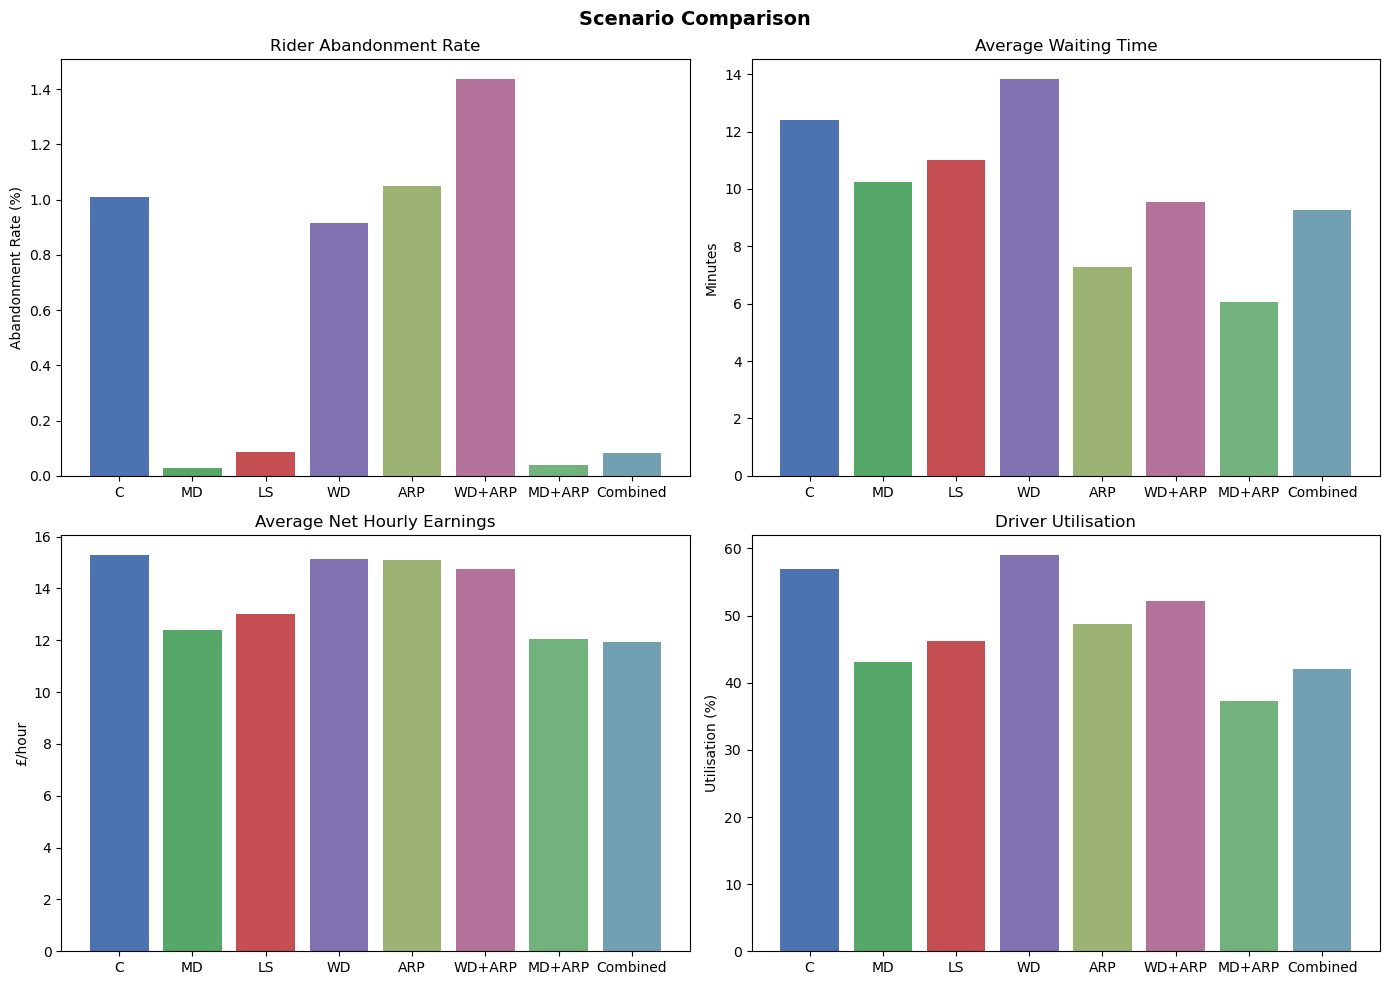

In [76]:

names = list(scenarios_calibrated.keys())
short_names = ["C", "MD", "LS", "WD", "ARP", "WD+ARP", "MD+ARP", "Combined"]
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#9CB272", "#B27299", "#72B27D", "#72A0B2"]


fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Abandonment rate
vals = [scenarios_calibrated[n]["abandon_rate"]*100 for n in names]
axes[0,0].bar(short_names, vals, color=colors)
axes[0,0].set_ylabel("Abandonment Rate (%)")
axes[0,0].set_title("Rider Abandonment Rate")

# Average waiting time
vals = [scenarios_calibrated[n]["avg_wait"]*60 for n in names]
axes[0,1].bar(short_names, vals, color=colors)
axes[0,1].set_ylabel("Minutes")
axes[0,1].set_title("Average Waiting Time")

# Hourly net earnings
vals = [scenarios_calibrated[n]["avg_hourly_net"] for n in names]
axes[1,0].bar(short_names, vals, color=colors)
axes[1,0].set_ylabel("£/hour")
axes[1,0].set_title("Average Net Hourly Earnings")

# Utilisation
vals = [scenarios_calibrated[n]["avg_utilisation"]*100 for n in names]
axes[1,1].bar(short_names, vals, color=colors)
axes[1,1].set_ylabel("Utilisation (%)")
axes[1,1].set_title("Driver Utilisation")

plt.suptitle("Scenario Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [80]:
import numpy as np
import pandas as pd
from scipy.stats import t as t_dist

def ci_95(data):
    """Compute 95% CI for a list of replication values."""
    n = len(data)
    if n < 2:
        return (data[0], data[0], data[0]) if data else (0,0,0)
    mean = np.mean(data)
    se = np.std(data, ddof=1) / np.sqrt(n)
    t_crit = t_dist.ppf(0.975, df=n-1)
    return (mean - t_crit*se, mean, mean + t_crit*se)

def paired_ci_95(data_a, data_b):
    """Paired-difference 95% CI: tests H0: mean(A) = mean(B).
    Returns (lower, mean_diff, upper, p_value).
    Positive diff means A > B."""
    diffs = np.array(data_a) - np.array(data_b)
    n = len(diffs)
    mean_d = np.mean(diffs)
    se_d = np.std(diffs, ddof=1) / np.sqrt(n)
    t_stat = mean_d / se_d if se_d > 0 else 0
    p_val = 2 * (1 - t_dist.cdf(abs(t_stat), df=n-1))
    t_crit = t_dist.ppf(0.975, df=n-1)
    return (mean_d - t_crit*se_d, mean_d, mean_d + t_crit*se_d, p_val)

# Collect per rep values for key metrics
def extract_metric(results_list, key):
    return [r[key] for r in results_list]

metrics_of_interest = {
    "Abandon Rate":     "abandon_rate",
    "Avg Wait (hrs)":   "avg_wait",
    "P90 Wait (hrs)":   "p90_wait",
    "Hourly Net (£)":   "avg_hourly_net",
    "Utilisation":      "avg_utilisation",
}

all_results = {
    "Baseline (spec)": baseline_results,
    "Calibrated (data)": calibrated_results,

    "Baseline adj + More drivers": imp1_results_b,
    "Baseline adj + Longer shifts": imp2_results_b,
    "Baseline adj + Weighted distance": imp3_results_b,
    "Baseline adj + Ring": ring_results_b,

    "Calibrated + More drivers": imp1_results_c,
    "Calibrated + Longer shifts": imp2_results_c,
    "Calibrated + Weighted distance": imp3_results_c,
    "Calibrated + Ring": ring_results_c,
}

print("=" * 90)
print("  95% CONFIDENCE INTERVALS (per scenario, per metric)")
print("=" * 90)
for metric_name, key in metrics_of_interest.items():
    print(f"\n--- {metric_name} ---")
    for scen_name, res_list in all_results.items():
        vals = extract_metric(res_list, key)
        lo, mid, hi = ci_95(vals)
        # Format nicely
        if "Wait" in metric_name:
            print(f"  {scen_name:<24}  {mid*60:>7.2f} min  [{lo*60:.2f}, {hi*60:.2f}]")
        elif "Rate" in metric_name or "Util" in metric_name:
            print(f"  {scen_name:<24}  {mid*100:>7.2f}%    [{lo*100:.2f}%, {hi*100:.2f}%]")
        else:
            print(f"  {scen_name:<24}  {mid:>7.2f}      [{lo:.2f}, {hi:.2f}]")

  95% CONFIDENCE INTERVALS (per scenario, per metric)

--- Abandon Rate ---
  Baseline (spec)             31.66%    [31.02%, 32.29%]
  Calibrated (data)            1.01%    [0.88%, 1.13%]
  Baseline adj + More drivers     1.24%    [1.08%, 1.40%]
  Baseline adj + Longer shifts     1.04%    [0.88%, 1.20%]
  Baseline adj + Weighted distance    10.54%    [10.12%, 10.95%]
  Baseline adj + Ring          9.66%    [9.20%, 10.12%]
  Calibrated + More drivers     0.03%    [0.01%, 0.04%]
  Calibrated + Longer shifts     0.09%    [0.07%, 0.11%]
  Calibrated + Weighted distance     0.92%    [0.81%, 1.02%]
  Calibrated + Ring            1.05%    [0.91%, 1.19%]

--- Avg Wait (hrs) ---
  Baseline (spec)             31.19 min  [30.91, 31.47]
  Calibrated (data)           12.39 min  [12.28, 12.49]
  Baseline adj + More drivers    11.55 min  [11.34, 11.76]
  Baseline adj + Longer shifts    11.10 min  [10.90, 11.29]
  Baseline adj + Weighted distance    23.33 min  [23.10, 23.56]
  Baseline adj + Ring     

In [81]:
# paired-difference test, each improvement vs calibrated baseline
print("=" * 100)
print("  PAIRED-DIFFERENCE TESTS vs CALIBRATED BASELINE")
print("  (positive diff = improvement scenario has HIGHER value than calibrated)")
print("=" * 100)

reference = "Calibrated (data)"
comparisons = [k for k in all_results if k != "Baseline (spec)" and k != reference]

for metric_name, key in metrics_of_interest.items():
    print(f"\n--- {metric_name} ---")
    ref_vals = extract_metric(all_results[reference], key)
    for scen_name in comparisons:
        scen_vals = extract_metric(all_results[scen_name], key)
        lo, md, hi, pval = paired_ci_95(scen_vals, ref_vals)
        sig = "***" if pval < 0.001 else ("**" if pval < 0.01 else ("*" if pval < 0.05 else ""))
        if "Wait" in metric_name:
            print(f"  {scen_name:<24} diff={md*60:>+7.2f}min  "
                  f"CI=[{lo*60:+.2f}, {hi*60:+.2f}]  p={pval:.4f} {sig}")
        elif "Rate" in metric_name or "Util" in metric_name:
            print(f"  {scen_name:<24} diff={md*100:>+7.2f}pp   "
                  f"CI=[{lo*100:+.2f}pp, {hi*100:+.2f}pp]  p={pval:.4f} {sig}")
        else:
            print(f"  {scen_name:<24} diff={md:>+7.2f}      "
                  f"CI=[{lo:+.2f}, {hi:+.2f}]  p={pval:.4f} {sig}")

print("\n* p<0.05, ** p<0.01, *** p<0.001")

  PAIRED-DIFFERENCE TESTS vs CALIBRATED BASELINE
  (positive diff = improvement scenario has HIGHER value than calibrated)

--- Abandon Rate ---
  Baseline adj + More drivers diff=  +0.24pp   CI=[+0.04pp, +0.43pp]  p=0.0165 *
  Baseline adj + Longer shifts diff=  +0.03pp   CI=[-0.18pp, +0.24pp]  p=0.7589 
  Baseline adj + Weighted distance diff=  +9.53pp   CI=[+9.09pp, +9.96pp]  p=0.0000 ***
  Baseline adj + Ring      diff=  +8.66pp   CI=[+8.18pp, +9.13pp]  p=0.0000 ***
  Calibrated + More drivers diff=  -0.98pp   CI=[-1.11pp, -0.85pp]  p=0.0000 ***
  Calibrated + Longer shifts diff=  -0.92pp   CI=[-1.05pp, -0.80pp]  p=0.0000 ***
  Calibrated + Weighted distance diff=  -0.09pp   CI=[-0.26pp, +0.08pp]  p=0.2892 
  Calibrated + Ring        diff=  +0.04pp   CI=[-0.15pp, +0.23pp]  p=0.6662 

--- Avg Wait (hrs) ---
  Baseline adj + More drivers diff=  -0.83min  CI=[-1.04, -0.63]  p=0.0000 ***
  Baseline adj + Longer shifts diff=  -1.29min  CI=[-1.52, -1.06]  p=0.0000 ***
  Baseline adj + We

Comparing all of these proposed alterations to policy with a baseline of just the calibrated parameters simulation, we make teh following assumptions surrounding the preferences of both drivers and riders:

***Drivers***

First, we assume that drivers prefer a higher hourly net income measured in (£/hr), as well as that they would prefer less intensive work, as suggested by a a lower utilisation percentage. This utilisation assumption arises from the preference of drivers to have adequate rest during their shift from the document spec. However, there is indeed a balancing act to both of these since lower utilisation does inherently impact a drivers income, and viceversa. We consider this to be less important than the driver's hourly net income but still must take it into consideration. 

***Riders***

We are primarily concerned with the abandonment rate being low as a metric as this is directly impactful to the rider perhaps using the BoxCar services frequently if they can consistently be matched with a driver within their patience window, and on top of this we assume that they prefer lower wait times both on average and at the $90^{\text{th}}$ percentile waiting time. Having lower abandonment rates directly improves the revenue gained by drivers and low waiting times benefits both the welfare of drivers and riders alike. 

Viewing the above (and below for visualisation) summaries, we see that all polcies except for only implementing an adaptive ring policy have a statistically significant reduction in abandonment rate.

All proposed improvements are significant in terms of reducing the average and $90^{\text{th}}$ percentile waiting times, with both improvements involving a ring policy offering the largest reductions compared to a baseline simulation. 

However, in terms of driver-specific performance metrics, by implementing only the adaptive ring policy we do not observe a statistically significant decrease in driver's net revenue, with all other policies decreasing driver net income at the 5% confidence level. Furthermore, every policy implemented did in fact reduce the average utilisation of drivers 

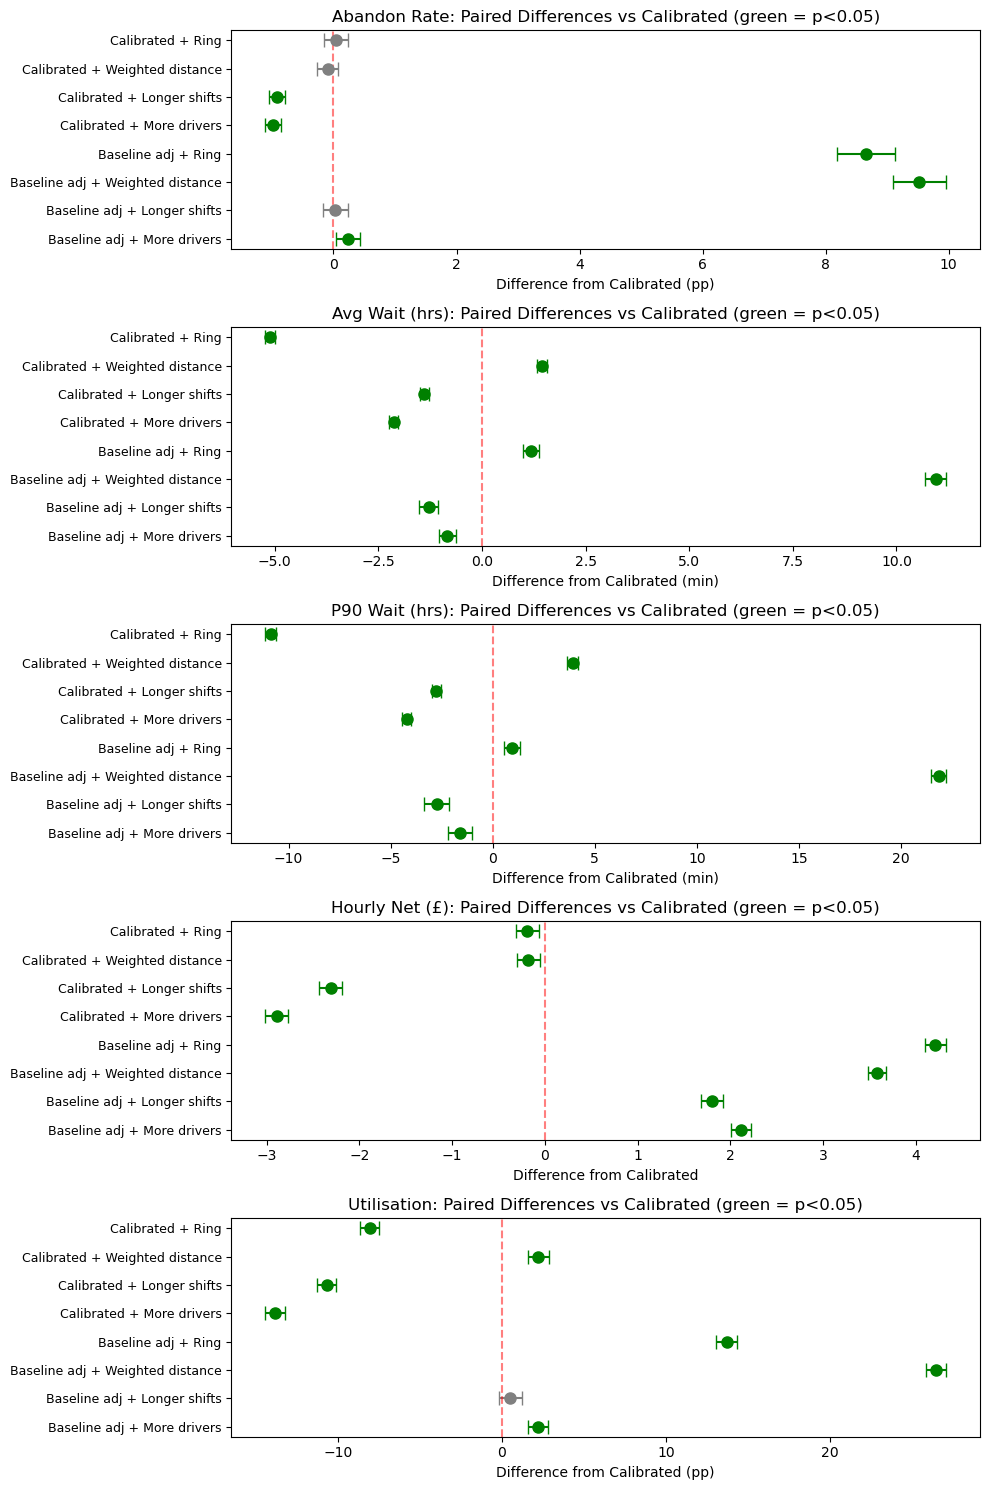

In [82]:
# plot of paired differences for avg wait time
fig, axes = plt.subplots(len(metrics_of_interest), 1, figsize=(10, 3*len(metrics_of_interest)))

ref_name = "Calibrated (data)"
comp_names = [k for k in all_results if k != "Baseline (spec)" and k != ref_name]

for ax_idx, (metric_name, key) in enumerate(metrics_of_interest.items()):
    ax = axes[ax_idx]
    ref_vals = extract_metric(all_results[ref_name], key)
    
    y_positions = range(len(comp_names))
    for i, scen in enumerate(comp_names):
        scen_vals = extract_metric(all_results[scen], key)
        lo, md_val, hi, pval = paired_ci_95(scen_vals, ref_vals)
        
        multiplier = 60 if "Wait" in metric_name else (100 if ("Rate" in metric_name or "Util" in metric_name) else 1)
        color = 'green' if pval < 0.05 else 'gray'
        ax.errorbar(md_val*multiplier, i, 
                    xerr=[[md_val*multiplier - lo*multiplier], [hi*multiplier - md_val*multiplier]],
                    fmt='o', color=color, capsize=5, markersize=8)
    
    ax.axvline(0, color='red', linestyle='--', alpha=0.5)
    ax.set_yticks(list(y_positions))
    ax.set_yticklabels(comp_names, fontsize=9)
    unit = " (min)" if "Wait" in metric_name else (" (pp)" if "Rate" in metric_name or "Util" in metric_name else "")
    ax.set_xlabel(f"Difference from Calibrated{unit}")
    ax.set_title(f"{metric_name}: Paired Differences vs Calibrated (green = p<0.05)")

plt.tight_layout()
plt.show()

---
# Conclusions and Recommendations

The underlying system assumptions derived from the cut of sample data diverge substantially from those provided by BoxCar. We should confirm with BoxCar whether or not the sample has been drawn from a period of atypical system behaviour, and if not, should seek further clarification that might help explain the departure, possibly from further business intelligence BoxCar could provide.

BoxCar's assumptions regarding driver supply and rider demand lead to an implausibly high abandonment rate (31.66%). We should raise this with BoxCar and confirm whether or not it is appropriate to use the sample derived distributions for driver inter-arrival and rider inter-arrival times.

Regarding the proposed improvements starting from the baseline adjusted assumptions, the best rider experience results from a combination of including more drivers and the adaptive ring driver relocation policy, but these two changes result in the worst driver experience, highlighting the tension between rider satisfaction and driver income and income fairness. No single tested improvement or combination of improvements resulted in a clear, unambiguously improved driver experience across all metrics.

Regarding the proposed improvements starting from the calibrated sample data assumptions, again, the best rider experience results from a combination of including more drivers and the adaptive ring driver relocation policy, and the best driver experience results from weighting the distance calculations and the adaptive ring relocation policy.

Given improvement criteria are being evaluated within the context of a multi-objective optimization problem, with demonstrably conflicting objectives, to target possible changes more effectively we should ask BoxCar if there are service targets they want to meet at a minimum. For example, clearly it is better if rider abandonment rates and waiting times are lower, but are there performance targets, such as rider abandonment percentage being <1% and average rider wait times being under 10 minutes, that we can use to benchmark possible improvements, and thereby suggest improvements which provide an acceptable middle ground.

Finally, we have only run 100 simulations, and should likely increase this number substantially to deliver more robust results when some of the above concerns have been dealt with.
